# CS3807 – Deep Learning Laboratory | Experiment 6 – Part 1
## Human Activity Recognition (UCI HAR, raw inertial signals) with Vanilla RNN, LSTM and GRU

### 1. Title and Experiment Objective
The objective of this part of Experiment 6 is to build an end-to-end understanding of recurrent sequence learning by
implementing and comparing **Vanilla RNN, LSTM and GRU** classifiers on the **UCI Human Activity Recognition Using
Smartphones** dataset (raw inertial signals, input `X ∈ R^(N×128×9)`).

The notebook covers: data loading and preprocessing, temporal visualisation, a manual RNN numerical exercise,
three controlled recurrent models, training/validation curves, test-set evaluation (Accuracy, macro Precision / Recall / F1,
confusion matrices, parameters, training time), an architecture comparison, the effect of sequence length (T = 32, 64, 128),
and auto-generated inferences and conclusions based **only on the measured results**.

**Pipeline:** Raw Sensor Signals → Windowing (128 × 9) → Normalization → RNN / LSTM / GRU → Dense → Softmax → Activity Class

**Controlled comparison:** the three models share the same data, split, normalisation, optimiser (Adam, lr = 1e-3),
batch size (32), epochs (30), loss (sparse categorical cross-entropy), output layers and evaluation protocol.
Only the recurrent layer (SimpleRNN / LSTM / GRU, 32 units) changes.

## 2. Import Libraries

In [1]:
import os
import time
import zipfile
import urllib.request
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report)
from IPython.display import display

warnings.filterwarnings("ignore")
print("TensorFlow version:", tf.__version__)
print("GPUs visible      :", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPUs visible      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 3. Configuration / Random Seeds
All hyper-parameters are defined here once and shared by RNN, LSTM and GRU.
`MANUAL_DATASET_PATH` is the fallback path you can change if automatic download/discovery fails.

In [2]:
# ---------------- Reproducibility ----------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

# ---------------- Dataset / subset configuration ----------------
# Fallback: point this to the folder that contains 'train/' and 'test/' (the "UCI HAR Dataset" folder), e.g.
# MANUAL_DATASET_PATH = "/kaggle/input/<your-dataset>/UCI HAR Dataset"
MANUAL_DATASET_PATH = None

DOWNLOAD_URLS = [
    "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip",
    "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip",
]

# Balanced subset: 400 windows per class -> 2400 windows in total -> 70% / 15% / 15%
TRAIN_PER_CLASS = 280      # 280 x 6 = 1680  (70%)
VAL_PER_CLASS = 60         #  60 x 6 =  360  (15%)  (validation is carved out of the OFFICIAL TRAIN partition)
TEST_PER_CLASS = 60        #  60 x 6 =  360  (15%)  (test comes from the OFFICIAL TEST partition)

# ---------------- Model / training configuration (identical for RNN, LSTM, GRU) ----------------
SEQ_LEN = 128
N_FEATURES = 9
N_CLASSES = 6
UNITS = 32
DROPOUT = 0.2
DENSE_UNITS = 16
LEARNING_RATE = 1e-3
BATCH_SIZE = 32
EPOCHS = 30
SEQ_LENGTHS = [32, 64, 128]

ACTIVITY_NAMES = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS", "SITTING", "STANDING", "LAYING"]
SIGNAL_NAMES = ["body_acc_x", "body_acc_y", "body_acc_z",
                "body_gyro_x", "body_gyro_y", "body_gyro_z",
                "total_acc_x", "total_acc_y", "total_acc_z"]
MODEL_NAMES = ["RNN", "LSTM", "GRU"]

# ---------------- Output folders ----------------
ON_KAGGLE = Path("/kaggle/working").exists()
WORK_DIR = Path("/kaggle/working") if ON_KAGGLE else Path.cwd()
OUT_DIR = WORK_DIR / "experiment6_part1_outputs"
DIRS = {n: OUT_DIR / n for n in ["plots", "confusion_matrices", "model_results", "tables", "diagrams"]}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

# ---------------- Global plot style (report quality) ----------------
plt.rcParams.update({
    "font.size": 12, "axes.titlesize": 15, "axes.labelsize": 13,
    "axes.titleweight": "bold", "axes.labelweight": "bold",
    "figure.titleweight": "bold", "xtick.labelsize": 11, "ytick.labelsize": 11,
    "legend.fontsize": 11, "axes.grid": True, "grid.alpha": 0.3,
    "figure.dpi": 100, "savefig.dpi": 300,
})
sns.set_palette("deep")

REPORT = []   # every auto-generated text block is stored here and saved at the end


def emit(text=""):
    """Print a line and keep it for the saved text report."""
    print(text)
    REPORT.append(text)


def save_fig(fig, folder, filename, tight=True):
    """Save a figure at 300 DPI into the given output sub-folder, then show it."""
    if tight:
        fig.tight_layout()
    path = DIRS[folder] / filename
    fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)
    print(f"[saved] {path}")


def save_table(df, folder, filename, index=False):
    path = DIRS[folder] / filename
    df.to_csv(path, index=index)
    print(f"[saved] {path}")


print("Output root:", OUT_DIR)

Output root: /kaggle/working/experiment6_part1_outputs


## 4. Dataset Download / Access
The notebook (1) uses `MANUAL_DATASET_PATH` if given, (2) searches `/kaggle/input` and earlier downloads for the raw
`Inertial Signals` folders, and (3) otherwise downloads the official zip from the UCI repository
(requires **Internet: On** in the Kaggle notebook settings).

In [4]:
def find_har_root(search_dirs):
    """Return the folder that contains train/Inertial Signals and test/Inertial Signals, or None."""
    for base in search_dirs:
        base = Path(base)
        if not base.exists():
            continue
        for f in base.rglob("body_acc_x_train.txt"):
            root = f.parent.parent.parent
            if ((root / "test" / "Inertial Signals" / "body_acc_x_test.txt").exists()
                    and (root / "train" / "y_train.txt").exists()):
                return root
    return None


def download_and_extract_har(dest_dir):
    """Download the UCI HAR zip (handles the nested 'UCI HAR Dataset.zip') and return the dataset root."""
    dest_dir.mkdir(parents=True, exist_ok=True)
    zip_path = dest_dir / "uci_har_download.zip"
    for url in DOWNLOAD_URLS:
        try:
            print("Trying to download:", url)
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=180) as resp, open(zip_path, "wb") as fh:
                fh.write(resp.read())
            with zipfile.ZipFile(zip_path) as z:
                z.extractall(dest_dir)
            for nested in list(dest_dir.rglob("*.zip")):          # UCI zip contains an inner zip
                if nested != zip_path:
                    with zipfile.ZipFile(nested) as z:
                        z.extractall(nested.parent)
            root = find_har_root([dest_dir])
            if root is not None:
                return root
        except Exception as err:                                  # try the next URL
            print("  -> failed:", err)
    return None


DATA_DIR = WORK_DIR / "uci_har_data"
HAR_ROOT = None
if MANUAL_DATASET_PATH:
    HAR_ROOT = find_har_root([MANUAL_DATASET_PATH])
if HAR_ROOT is None:
    HAR_ROOT = find_har_root([Path("/kaggle/input"), DATA_DIR])
if HAR_ROOT is None:
    print("Dataset not found locally -> downloading from UCI ...")
    HAR_ROOT = download_and_extract_har(DATA_DIR)
if HAR_ROOT is None:
    raise FileNotFoundError(
        "Could not locate or download the UCI HAR raw inertial signals.\n"
        "Fix: (a) turn Internet ON in the Kaggle notebook settings and re-run, OR\n"
        "     (b) add any Kaggle dataset that contains the original 'UCI HAR Dataset' folder (with 'Inertial Signals'), OR\n"
        "     (c) set MANUAL_DATASET_PATH in the configuration cell to the folder that contains 'train' and 'test'.")

print("Dataset location:", HAR_ROOT)

Dataset not found locally -> downloading from UCI ...
Trying to download: https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip
Dataset location: /kaggle/working/uci_har_data/UCI HAR Dataset


## 5. Dataset Exploration

In [5]:
print("Top-level content of the dataset folder:")
for p in sorted(HAR_ROOT.iterdir()):
    print("  -", p.name + ("/" if p.is_dir() else ""))

print("\nRaw signal file structure (train/Inertial Signals):")
for f in sorted((HAR_ROOT / "train" / "Inertial Signals").glob("*.txt")):
    print("  -", f.name)
print("\nEach row of a signal file = ONE window of 128 time steps (2.56 s at 50 Hz, 50% overlap).")
print("The 9 signals used as channels (in this order):", SIGNAL_NAMES)

# Activity label mapping from the dataset itself (cross-checked with our class list)
labels_file = pd.read_csv(HAR_ROOT / "activity_labels.txt", sep=r"\s+", header=None, names=["id", "name"])
print("\nActivity classes in dataset:", dict(zip(labels_file["id"], labels_file["name"])))
assert list(labels_file["name"]) == ACTIVITY_NAMES, "Activity order differs from ACTIVITY_NAMES!"

# Official partition sizes and class counts (from the label files only)
official = {}
for split in ["train", "test"]:
    y_split = pd.read_csv(HAR_ROOT / split / f"y_{split}.txt", header=None).values.ravel() - 1
    subj = pd.read_csv(HAR_ROOT / split / f"subject_{split}.txt", header=None).values.ravel()
    official[split] = y_split
    print(f"Official {split:5s} partition: {len(y_split)} windows from {len(np.unique(subj))} subjects")

official_counts = pd.DataFrame({
    "Activity": ACTIVITY_NAMES,
    "Official train windows": np.bincount(official["train"], minlength=N_CLASSES),
    "Official test windows": np.bincount(official["test"], minlength=N_CLASSES)})
display(official_counts)
save_table(official_counts, "tables", "00_official_class_counts.csv")

Top-level content of the dataset folder:
  - .DS_Store
  - README.txt
  - activity_labels.txt
  - features.txt
  - features_info.txt
  - test/
  - train/

Raw signal file structure (train/Inertial Signals):
  - body_acc_x_train.txt
  - body_acc_y_train.txt
  - body_acc_z_train.txt
  - body_gyro_x_train.txt
  - body_gyro_y_train.txt
  - body_gyro_z_train.txt
  - total_acc_x_train.txt
  - total_acc_y_train.txt
  - total_acc_z_train.txt

Each row of a signal file = ONE window of 128 time steps (2.56 s at 50 Hz, 50% overlap).
The 9 signals used as channels (in this order): ['body_acc_x', 'body_acc_y', 'body_acc_z', 'body_gyro_x', 'body_gyro_y', 'body_gyro_z', 'total_acc_x', 'total_acc_y', 'total_acc_z']

Activity classes in dataset: {1: 'WALKING', 2: 'WALKING_UPSTAIRS', 3: 'WALKING_DOWNSTAIRS', 4: 'SITTING', 5: 'STANDING', 6: 'LAYING'}
Official train partition: 7352 windows from 21 subjects
Official test  partition: 2947 windows from 9 subjects


,Activity,Official train windows,Official test windows
0,WALKING,1226,496
1,WALKING_UPSTAIRS,1073,471
2,WALKING_DOWNSTAIRS,986,420
3,SITTING,1286,491
4,STANDING,1374,532
5,LAYING,1407,537


[saved] /kaggle/working/experiment6_part1_outputs/tables/00_official_class_counts.csv


## 6. Raw Signal Loading
Every window is arranged as `(128, 9)` and stacked into `X ∈ R^(N×128×9)`. The 561-feature files are **not** used.

In [6]:
def load_split(split):
    """Load the 9 raw inertial signals of one official partition -> X (N,128,9), y (N,), subjects (N,)."""
    base = HAR_ROOT / split
    channels = []
    for name in SIGNAL_NAMES:
        f = base / "Inertial Signals" / f"{name}_{split}.txt"
        if not f.exists():
            raise FileNotFoundError(f"Missing raw signal file: {f}")
        channels.append(pd.read_csv(f, sep=r"\s+", header=None).values.astype(np.float32))   # (N,128)
    X = np.stack(channels, axis=-1)                                                          # (N,128,9)
    y = pd.read_csv(base / f"y_{split}.txt", header=None).values.ravel().astype(int) - 1     # 0..5
    subjects = pd.read_csv(base / f"subject_{split}.txt", header=None).values.ravel()
    assert X.shape[1:] == (SEQ_LEN, N_FEATURES), f"Unexpected window shape {X.shape}"
    assert len(X) == len(y) == len(subjects), "Signals/labels/subjects length mismatch"
    return X, y, subjects


t0 = time.perf_counter()
X_off_train, y_off_train, subj_off_train = load_split("train")
X_off_test, y_off_test, subj_off_test = load_split("test")
print(f"Loaded raw signals in {time.perf_counter() - t0:.1f} s")
print("Official train tensor:", X_off_train.shape, "| labels:", y_off_train.shape)
print("Official test  tensor:", X_off_test.shape, "| labels:", y_off_test.shape)
print("Total windows loaded :", len(X_off_train) + len(X_off_test))

Loaded raw signals in 3.3 s
Official train tensor: (7352, 128, 9) | labels: (7352,)
Official test  tensor: (2947, 128, 9) | labels: (2947,)
Total windows loaded : 10299


## 7. Data Preprocessing
1. Raw signals were loaded and arranged as 128 × 9 windows; one activity label per window (0–5).
2. A **class-balanced** subset (400 windows/class = 2400) is drawn with a fixed seed:
   * 340 windows/class from the **official train** partition → split (stratified) into **280 train + 60 validation** per class;
   * 60 windows/class from the **official test** partition → **test** (never used for any decision).
   This gives exactly **70% / 15% / 15%**, and the test subjects are different from the training subjects.
3. Normalisation uses **channel-wise mean/std computed on the training set only**.

*Note:* HAR windows overlap by 50%, so a random train/validation split can put neighbouring windows in both sets; validation scores
can therefore be slightly optimistic. The test set is unaffected because it comes from different subjects.

In [7]:
def balanced_indices(y, per_class, rng):
    """Random, reproducible, class-balanced index selection."""
    chosen = []
    for c in range(N_CLASSES):
        candidates = np.where(y == c)[0]
        if len(candidates) < per_class:
            raise ValueError(f"Class {c} has only {len(candidates)} windows, need {per_class}")
        chosen.append(rng.choice(candidates, size=per_class, replace=False))
    chosen = np.concatenate(chosen)
    rng.shuffle(chosen)
    return chosen


rng = np.random.default_rng(SEED)
idx_trainval = balanced_indices(y_off_train, TRAIN_PER_CLASS + VAL_PER_CLASS, rng)
idx_test = balanced_indices(y_off_test, TEST_PER_CLASS, rng)

X_trainval, y_trainval = X_off_train[idx_trainval], y_off_train[idx_trainval]
X_test_raw, y_test = X_off_test[idx_test], y_off_test[idx_test]

# Validation split from TRAIN data only (stratified)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=VAL_PER_CLASS * N_CLASSES, stratify=y_trainval, random_state=SEED)

# Normalisation statistics from the TRAINING set only (per channel over all windows and time steps)
train_mean = X_train_raw.mean(axis=(0, 1), keepdims=True)
train_std = X_train_raw.std(axis=(0, 1), keepdims=True) + 1e-8
X_train = ((X_train_raw - train_mean) / train_std).astype(np.float32)
X_val = ((X_val_raw - train_mean) / train_std).astype(np.float32)
X_test = ((X_test_raw - train_mean) / train_std).astype(np.float32)

norm_table = pd.DataFrame({"Channel": SIGNAL_NAMES,
                           "Train mean": train_mean.ravel(), "Train std": train_std.ravel(),
                           "Norm. train mean": X_train.mean(axis=(0, 1)), "Norm. train std": X_train.std(axis=(0, 1))})
display(norm_table.round(4))
save_table(norm_table, "tables", "01_normalization_statistics.csv")

total_used = len(X_train) + len(X_val) + len(X_test)
print(f"\nWindows actually used: {total_used}  "
      f"(train {len(X_train)} = {100*len(X_train)/total_used:.1f}%, "
      f"val {len(X_val)} = {100*len(X_val)/total_used:.1f}%, "
      f"test {len(X_test)} = {100*len(X_test)/total_used:.1f}%)")

,Channel,Train mean,Train std,Norm. train mean,Norm. train std
0,body_acc_x,-0.0004,0.2091,-0.0,1.0
1,body_acc_y,-0.0006,0.1297,-0.0,1.0
2,body_acc_z,-0.0003,0.1125,0.0,1.0
3,body_gyro_x,-0.0024,0.4330,-0.0,1.0
4,body_gyro_y,-0.0006,0.4064,0.0,1.0
5,body_gyro_z,-0.0024,0.2712,0.0,1.0
6,total_acc_x,0.8270,0.4035,0.0,1.0
7,total_acc_y,0.0059,0.3804,-0.0,1.0
8,total_acc_z,0.0708,0.3479,0.0,1.0


[saved] /kaggle/working/experiment6_part1_outputs/tables/01_normalization_statistics.csv

Windows actually used: 2400  (train 1680 = 70.0%, val 360 = 15.0%, test 360 = 15.0%)


## 8. Dataset Shape Verification

In [8]:
assert X_train.shape == (len(y_train), SEQ_LEN, N_FEATURES)
assert X_val.shape == (len(y_val), SEQ_LEN, N_FEATURES)
assert X_test.shape == (len(y_test), SEQ_LEN, N_FEATURES)
assert not (np.isnan(X_train).any() or np.isnan(X_val).any() or np.isnan(X_test).any()), "NaNs found"
assert len(np.unique(y_train)) == len(np.unique(y_val)) == len(np.unique(y_test)) == N_CLASSES

print("Input tensor shape:")
print(f"Training   : {X_train.shape}")
print(f"Validation : {X_val.shape}")
print(f"Testing    : {X_test.shape}")
print(f"\nNumber of classes: {N_CLASSES}")
print(f"Number of features per time step: {X_train.shape[2]}")
print(f"Sequence length: {X_train.shape[1]}")
print("A batch of 32 samples has shape:", (BATCH_SIZE,) + X_train.shape[1:], "-> 3-D tensor (N, T, F)")

Input tensor shape:
Training   : (1680, 128, 9)
Validation : (360, 128, 9)
Testing    : (360, 128, 9)

Number of classes: 6
Number of features per time step: 9
Sequence length: 128
A batch of 32 samples has shape: (32, 128, 9) -> 3-D tensor (N, T, F)


## 9. Class Distribution

Split,Train,Validation,Test
Activity,,,
WALKING,280,60,60
WALKING_UPSTAIRS,280,60,60
WALKING_DOWNSTAIRS,280,60,60
SITTING,280,60,60
STANDING,280,60,60
LAYING,280,60,60


Split,Train,Validation,Test
Activity,,,
WALKING,16.67,16.67,16.67
WALKING_UPSTAIRS,16.67,16.67,16.67
WALKING_DOWNSTAIRS,16.67,16.67,16.67
SITTING,16.67,16.67,16.67
STANDING,16.67,16.67,16.67
LAYING,16.67,16.67,16.67


[saved] /kaggle/working/experiment6_part1_outputs/tables/02_class_distribution.csv


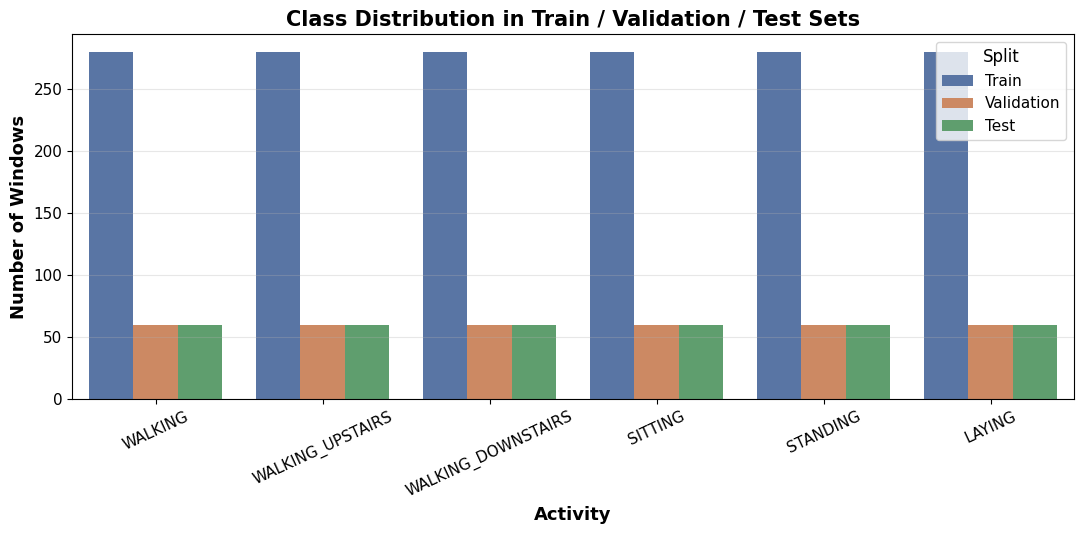

[saved] /kaggle/working/experiment6_part1_outputs/plots/00_class_distribution.png


In [9]:
def distribution_table(y, split_name):
    counts = np.bincount(y, minlength=N_CLASSES)
    return pd.DataFrame({"Split": split_name, "Activity": ACTIVITY_NAMES, "Count": counts,
                         "Percent (%)": np.round(100 * counts / counts.sum(), 2)})


dist_df = pd.concat([distribution_table(y_train, "Train"), distribution_table(y_val, "Validation"),
                     distribution_table(y_test, "Test")], ignore_index=True)
for value_col in ["Count", "Percent (%)"]:
    display(dist_df.pivot(index="Activity", columns="Split", values=value_col).loc[ACTIVITY_NAMES, ["Train", "Validation", "Test"]])
save_table(dist_df, "tables", "02_class_distribution.csv")

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.barplot(data=dist_df, x="Activity", y="Count", hue="Split", ax=ax)
ax.set_title("Class Distribution in Train / Validation / Test Sets")
ax.set_xlabel("Activity")
ax.set_ylabel("Number of Windows")
ax.tick_params(axis="x", rotation=25)
ax.legend(title="Split")
save_fig(fig, "plots", "00_class_distribution.png")

## 10. Temporal Data Visualization (Plot 1)
Representative windows (raw, un-normalised units) from **all six** activities are drawn for three channels
(`body_acc_x`, `body_gyro_x`, `total_acc_x`). Left column: walking-type (dynamic) activities; right column: SITTING, STANDING, LAYING.

Representative training-window indices: {'WALKING': 4, 'WALKING_UPSTAIRS': 2, 'WALKING_DOWNSTAIRS': 27, 'SITTING': 0, 'STANDING': 1, 'LAYING': 5}


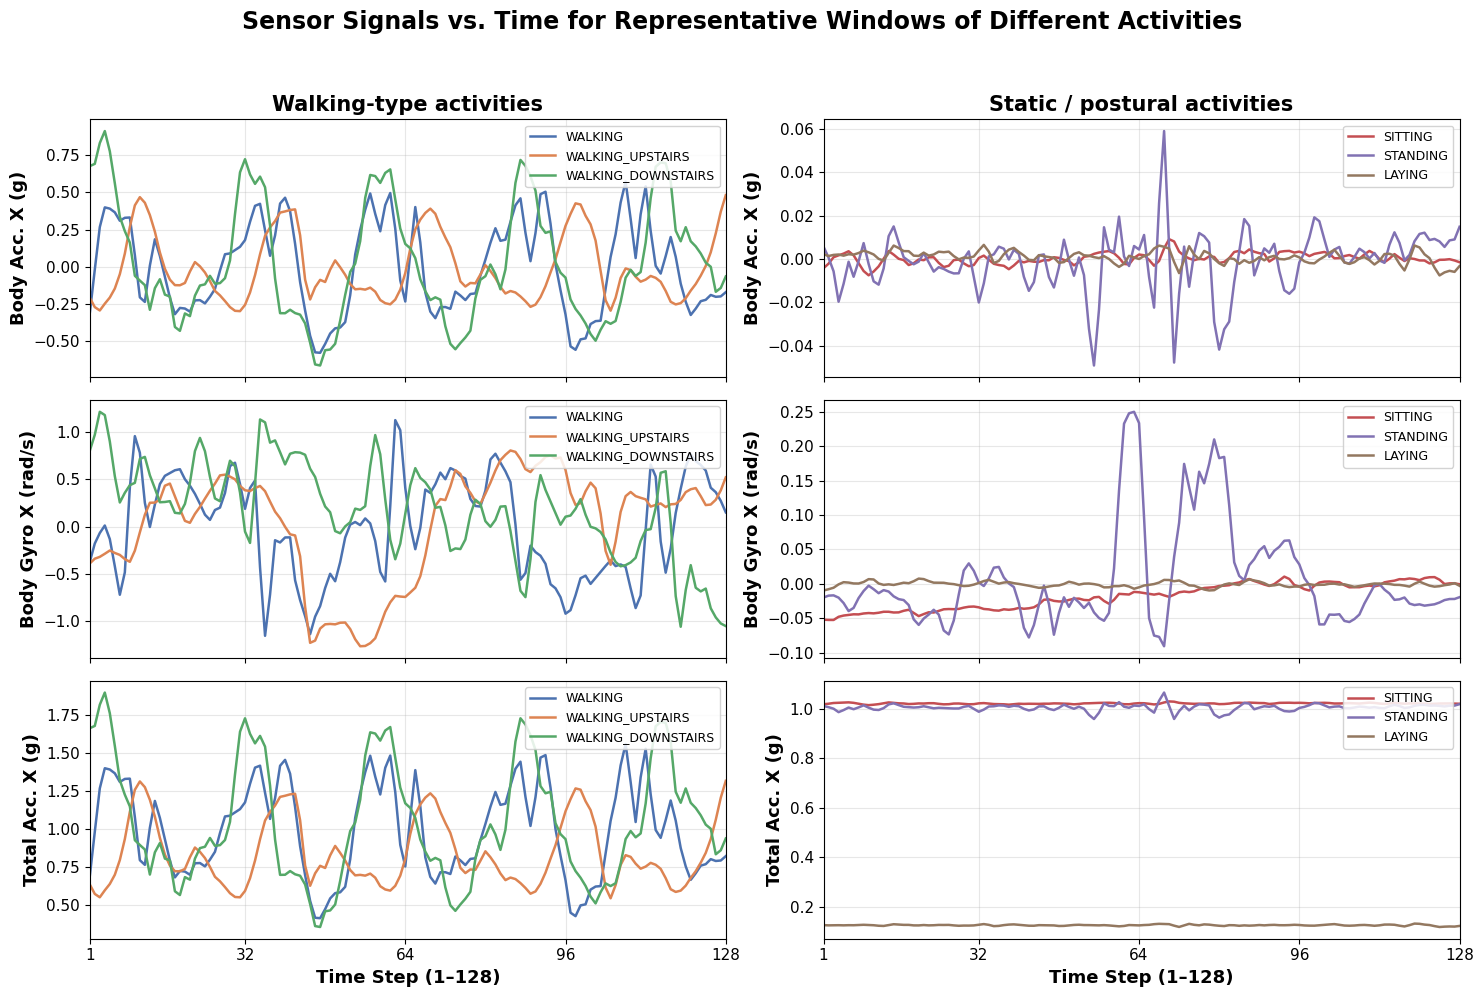

[saved] /kaggle/working/experiment6_part1_outputs/plots/01_temporal_sensor_signals.png


In [10]:
plot_channels = ["body_acc_x", "body_gyro_x", "total_acc_x"]
plot_ylabels = {"body_acc_x": "Body Acc. X (g)", "body_gyro_x": "Body Gyro X (rad/s)", "total_acc_x": "Total Acc. X (g)"}
column_groups = {"Walking-type activities": [0, 1, 2], "Static / postural activities": [3, 4, 5]}
colors = sns.color_palette("deep", N_CLASSES)
time_steps = np.arange(1, SEQ_LEN + 1)
representative_idx = {c: int(np.where(y_train == c)[0][0]) for c in range(N_CLASSES)}   # first training window per class
print("Representative training-window indices:", {ACTIVITY_NAMES[c]: i for c, i in representative_idx.items()})

fig, axes = plt.subplots(len(plot_channels), 2, figsize=(15, 10), sharex=True)
for r, ch in enumerate(plot_channels):
    ch_idx = SIGNAL_NAMES.index(ch)
    for col, (group_title, classes) in enumerate(column_groups.items()):
        ax = axes[r, col]
        for c in classes:
            ax.plot(time_steps, X_train_raw[representative_idx[c], :, ch_idx], color=colors[c], lw=1.8, label=ACTIVITY_NAMES[c])
        if r == 0:
            ax.set_title(group_title)
        ax.set_ylabel(plot_ylabels[ch])
        ax.set_xlim(1, SEQ_LEN)
        ax.set_xticks([1, 32, 64, 96, 128])
        ax.legend(loc="upper right", fontsize=9, framealpha=0.85)
        if r == len(plot_channels) - 1:
            ax.set_xlabel("Time Step (1–128)")
fig.suptitle("Sensor Signals vs. Time for Representative Windows of Different Activities", fontsize=17, y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.97])
save_fig(fig, "plots", "01_temporal_sensor_signals.png", tight=False)

### Quantitative description of the temporal patterns (computed from the training windows)

In [11]:
stats_rows = []
for c in range(N_CLASSES):
    Xc = X_train_raw[y_train == c]                       # (n,128,9)
    within_std = Xc.std(axis=1)                          # variability inside each window: (n,9)
    stats_rows.append({
        "Activity": ACTIVITY_NAMES[c],
        "Body-acc variability (std, g)": within_std[:, 0:3].mean(),
        "Body-gyro variability (std, rad/s)": within_std[:, 3:6].mean(),
        "Mean total-acc X (g)": Xc[:, :, 6].mean(),
        "Mean total-acc Y (g)": Xc[:, :, 7].mean(),
        "Mean total-acc Z (g)": Xc[:, :, 8].mean()})
temporal_stats = pd.DataFrame(stats_rows)
display(temporal_stats.round(4))
save_table(temporal_stats, "tables", "03_temporal_pattern_statistics.csv")

# Which classes look alike? z-score the 5 descriptors across classes and compare Euclidean distances.
desc = temporal_stats.drop(columns="Activity").values
desc_z = (desc - desc.mean(0)) / (desc.std(0) + 1e-12)
dist_mat = np.linalg.norm(desc_z[:, None, :] - desc_z[None, :, :], axis=-1)
pair_list = sorted([(dist_mat[i, j], i, j) for i in range(N_CLASSES) for j in range(i + 1, N_CLASSES)])
closest_pairs = [(ACTIVITY_NAMES[i], ACTIVITY_NAMES[j], float(d)) for d, i, j in pair_list[:3]]
farthest_pair = (ACTIVITY_NAMES[pair_list[-1][1]], ACTIVITY_NAMES[pair_list[-1][2]], float(pair_list[-1][0]))
variability_rank = temporal_stats.sort_values("Body-acc variability (std, g)", ascending=False)["Activity"].tolist()

temporal_info = {"closest_pairs": closest_pairs, "farthest_pair": farthest_pair, "variability_rank": variability_rank}
print("Activities ranked by body-acceleration variability (high -> low):", variability_rank)
print("Most similar activity pairs (descriptor distance):", [(a, b, round(d, 2)) for a, b, d in closest_pairs])
print("Most different activity pair:", (farthest_pair[0], farthest_pair[1], round(farthest_pair[2], 2)))

,Activity,"Body-acc variability (std, g)","Body-gyro variability (std, rad/s)",Mean total-acc X (g),Mean total-acc Y (g),Mean total-acc Z (g)
0,WALKING,0.1767,0.4353,0.9955,-0.1837,-0.0694
1,WALKING_UPSTAIRS,0.1938,0.4556,0.9477,-0.2726,-0.1694
2,WALKING_DOWNSTAIRS,0.2353,0.4954,0.9937,-0.1497,-0.0443
3,SITTING,0.0101,0.0206,0.9486,0.1530,0.1511
4,STANDING,0.0112,0.0342,1.0014,-0.1618,-0.0207
5,LAYING,0.0133,0.0275,0.0750,0.6503,0.5777


[saved] /kaggle/working/experiment6_part1_outputs/tables/03_temporal_pattern_statistics.csv
Activities ranked by body-acceleration variability (high -> low): ['WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS', 'WALKING', 'LAYING', 'STANDING', 'SITTING']
Most similar activity pairs (descriptor distance): [('WALKING', 'WALKING_UPSTAIRS', 0.55), ('WALKING', 'WALKING_DOWNSTAIRS', 0.68), ('WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 0.8)]
Most different activity pair: ('WALKING_UPSTAIRS', 'LAYING', 5.64)


## 11. Manual RNN Numerical Exercise
Given `x1 = 0.5, x2 = 0.7, x3 = 0.2, h0 = 0, Wx = 0.5, Wh = 0.8, b = 0.1` and `h_t = tanh(Wx·x_t + Wh·h_(t-1) + b)`.

**A. Manual (hand) calculation**
* t = 1: z1 = 0.5·0.5 + 0.8·0 + 0.1 = 0.35 → h1 = tanh(0.35) ≈ **0.3364**
* t = 2: z2 = 0.5·0.7 + 0.8·0.3364 + 0.1 = 0.35 + 0.2691 + 0.1 = 0.7191 → h2 = tanh(0.7191) ≈ **0.6164**
* t = 3: z3 = 0.5·0.2 + 0.8·0.6164 + 0.1 = 0.1 + 0.4931 + 0.1 = 0.6931 → h3 = tanh(0.6931) ≈ **0.6000**

**B. Program verification** – the same recurrence is computed with NumPy and also with a Keras `SimpleRNN` (1 unit) whose weights are set to Wx, Wh, b.

In [12]:
x_seq = [0.5, 0.7, 0.2]
Wx, Wh, b = 0.5, 0.8, 0.1
manual_h = [0.3364, 0.6164, 0.6000]          # hand-calculated values (4 decimals) from the working above

# (i) explicit recurrence in NumPy
h_prev, program_h = 0.0, []
for xt in x_seq:
    h_prev = np.tanh(Wx * xt + Wh * h_prev + b)
    program_h.append(float(h_prev))

# (ii) independent check with Keras SimpleRNN using the same weights
check_rnn = layers.SimpleRNN(1, activation="tanh", return_sequences=True)
_ = check_rnn(np.array(x_seq, dtype="float32").reshape(1, 3, 1))
check_rnn.set_weights([np.array([[Wx]], dtype="float32"), np.array([[Wh]], dtype="float32"), np.array([b], dtype="float32")])
keras_h = check_rnn(np.array(x_seq, dtype="float32").reshape(1, 3, 1)).numpy().ravel()

manual_table = pd.DataFrame({
    "Time Step": [1, 2, 3],
    "Manual h (hand, 4 d.p.)": manual_h,
    "Program h (NumPy)": program_h,
    "Keras SimpleRNN h": keras_h,
    "Difference |Manual − Program|": np.abs(np.array(manual_h) - np.array(program_h))})
pd.set_option("display.float_format", lambda v: f"{v:.8f}")
display(manual_table)
pd.reset_option("display.float_format")
print("NumPy and Keras agree:", np.allclose(program_h, keras_h, atol=1e-6))
print("Hand-calculated values match the program to within 1e-4:", bool(np.all(manual_table.iloc[:, -1] < 1e-4)))
save_table(manual_table, "tables", "04_manual_rnn_exercise.csv")

I0000 00:00:1789905412.569101      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789905412.571937      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


,Time Step,"Manual h (hand, 4 d.p.)",Program h (NumPy),Keras SimpleRNN h,Difference |Manual − Program|
0,1,0.33640000,0.33637554,0.33637553,0.00002446
1,2,0.61640000,0.61635178,0.61635178,0.00004822
2,3,0.60000000,0.59995792,0.59995794,0.00004208


NumPy and Keras agree: True
Hand-calculated values match the program to within 1e-4: True
[saved] /kaggle/working/experiment6_part1_outputs/tables/04_manual_rnn_exercise.csv


## 12. Vanilla RNN Model
`Input(128×9) → SimpleRNN(32) → Dropout(0.2) → Dense(16, ReLU) → Dense(6) → Softmax`
The same builder is used for LSTM and GRU; only the recurrent layer differs.

In [13]:
RECURRENT_LAYER = {"RNN": layers.SimpleRNN, "LSTM": layers.LSTM, "GRU": layers.GRU}


def build_model(model_name, seq_len=SEQ_LEN):
    """Identical classifier for all three models; only the recurrent layer changes."""
    keras.utils.set_random_seed(SEED)      # same seed before every build -> controlled comparison
    model = keras.Sequential([
        layers.Input(shape=(seq_len, N_FEATURES)),
        RECURRENT_LAYER[model_name](UNITS, name=f"{model_name.lower()}_layer"),
        layers.Dropout(DROPOUT),
        layers.Dense(DENSE_UNITS, activation="relu"),
        layers.Dense(N_CLASSES, name="logits"),
        layers.Softmax(),
    ], name=f"{model_name}_classifier")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


def trainable_params(model):
    return int(np.sum([np.prod(w.shape) for w in model.trainable_weights]))


def save_summary(model, filename):
    lines = []
    model.summary(print_fn=lambda line, **kw: lines.append(line))
    (DIRS["model_results"] / filename).write_text("\n".join(lines))


MODELS = {}
MODELS["RNN"] = build_model("RNN")
MODELS["RNN"].summary()
save_summary(MODELS["RNN"], "rnn_model_summary.txt")
print("RNN trainable parameters:", trainable_params(MODELS["RNN"]))

Model: "RNN_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn_layer (SimpleRNN)           │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 6)              │           102 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (None, 6)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,974 (7.71 KB)

 Trainable params: 1,974 (7.71 KB)

 Non-trainable params: 0 (0.00 B)

RNN trainable parameters: 1974


## 13. LSTM Model
Only the recurrent layer is replaced by `LSTM(32)`.

In [14]:
MODELS["LSTM"] = build_model("LSTM")
MODELS["LSTM"].summary()
save_summary(MODELS["LSTM"], "lstm_model_summary.txt")
print("LSTM trainable parameters:", trainable_params(MODELS["LSTM"]))

Model: "LSTM_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_layer (LSTM)               │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 6)              │           102 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_1 (Softmax)             │ (None, 6)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,006 (23.46 KB)

 Trainable params: 6,006 (23.46 KB)

 Non-trainable params: 0 (0.00 B)

LSTM trainable parameters: 6006


## 14. GRU Model
Only the recurrent layer is replaced by `GRU(32)`.

In [15]:
MODELS["GRU"] = build_model("GRU")
MODELS["GRU"].summary()
save_summary(MODELS["GRU"], "gru_model_summary.txt")
print("GRU trainable parameters:", trainable_params(MODELS["GRU"]))

# Sanity check of the parameter counts of the recurrent layers against the theoretical formulas
F, U = N_FEATURES, UNITS
expected_rec = {"RNN": F * U + U * U + U,                 # 1 weight set: input, recurrent, bias
                "LSTM": 4 * (F * U + U * U + U),          # 4 weight sets: forget, input, output gates + candidate
                "GRU": 3 * (F * U + U * U + 2 * U)}       # 3 weight sets: update, reset + candidate (Keras: 2 bias vectors)
for name in MODEL_NAMES:
    actual = MODELS[name].get_layer(f"{name.lower()}_layer").count_params()
    print(f"{name:5s} recurrent-layer params: Keras = {actual:5d} | formula = {expected_rec[name]:5d} | match = {actual == expected_rec[name]}")

Model: "GRU_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_layer (GRU)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 6)              │           102 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_2 (Softmax)             │ (None, 6)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,758 (18.59 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)

GRU trainable parameters: 4758
RNN   recurrent-layer params: Keras =  1344 | formula =  1344 | match = True
LSTM  recurrent-layer params: Keras =  5376 | formula =  5376 | match = True
GRU   recurrent-layer params: Keras =  4128 | formula =  4128 | match = True


## 15. Model Training
All three models use the **same** training data, validation data, optimiser (Adam, lr = 1e-3), batch size (32), 30 epochs and loss.
No early stopping / checkpointing is used, so the **validation set is only monitored** and the **test set is not touched** here.
Training time is measured with `time.perf_counter()` around `model.fit`.

In [16]:
class EpochLogger(keras.callbacks.Callback):
    """Compact progress print (every 5 epochs) to keep the notebook output short."""
    def __init__(self, name, every=5):
        super().__init__()
        self.name, self.every = name, every

    def on_epoch_end(self, epoch, logs=None):
        if epoch == 0 or (epoch + 1) % self.every == 0 or epoch + 1 == EPOCHS:
            print(f"  [{self.name}] epoch {epoch+1:2d}/{EPOCHS} | loss {logs['loss']:.4f} acc {logs['accuracy']:.4f} "
                  f"| val_loss {logs['val_loss']:.4f} val_acc {logs['val_accuracy']:.4f}")


def train_model(model, name, X_tr, y_tr, X_va, y_va, log=True):
    start = time.perf_counter()
    hist = model.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=EPOCHS, batch_size=BATCH_SIZE,
                     shuffle=True, verbose=0, callbacks=[EpochLogger(name)] if log else [])
    elapsed = time.perf_counter() - start
    return pd.DataFrame(hist.history), elapsed


def evaluate_model(model, X, y_true):
    """Accuracy + MACRO precision/recall/F1 (in %) and predictions."""
    y_pred = model.predict(X, batch_size=256, verbose=0).argmax(axis=1)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return {"accuracy": accuracy_score(y_true, y_pred) * 100, "precision": p * 100, "recall": r * 100, "f1": f1 * 100}, y_pred


RESULTS = {}
for name in MODEL_NAMES:
    print(f"\n=== Training {name} ===")
    history, train_time = train_model(MODELS[name], name, X_train, y_train, X_val, y_val)
    RESULTS[name] = {"history": history, "train_time": train_time, "params": trainable_params(MODELS[name])}
    print(f"  {name} finished in {train_time:.1f} s")
    save_table(history.assign(epoch=np.arange(1, len(history) + 1)), "model_results", f"{name.lower()}_training_history.csv")


=== Training RNN ===


I0000 00:00:1789905436.335109     139 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  [RNN] epoch  1/30 | loss 1.6481 acc 0.3637 | val_loss 1.5010 val_acc 0.4444
  [RNN] epoch  5/30 | loss 0.9719 acc 0.5929 | val_loss 0.9237 val_acc 0.6000
  [RNN] epoch 10/30 | loss 0.6887 acc 0.6845 | val_loss 0.6884 val_acc 0.6694
  [RNN] epoch 15/30 | loss 0.7593 acc 0.6827 | val_loss 0.7489 val_acc 0.6528
  [RNN] epoch 20/30 | loss 0.7653 acc 0.6589 | val_loss 0.7734 val_acc 0.6694
  [RNN] epoch 25/30 | loss 0.5925 acc 0.7458 | val_loss 0.5883 val_acc 0.7417
  [RNN] epoch 30/30 | loss 0.5963 acc 0.7488 | val_loss 0.5707 val_acc 0.7472
  RNN finished in 24.2 s
[saved] /kaggle/working/experiment6_part1_outputs/model_results/rnn_training_history.csv

=== Training LSTM ===
  [LSTM] epoch  1/30 | loss 1.6397 acc 0.3411 | val_loss 1.4581 val_acc 0.3861
  [LSTM] epoch  5/30 | loss 0.7472 acc 0.7042 | val_loss 0.6942 val_acc 0.7222
  [LSTM] epoch 10/30 | loss 0.3549 acc 0.8565 | val_loss 0.3229 val_acc 0.8667
  [LSTM] epoch 15/30 | loss 0.1739 acc 0.9351 | val_loss 0.2081 val_acc 0.9444
 

In [17]:
# Final-epoch training/validation numbers (measured, not hard-coded)
train_summary = pd.DataFrame([{
    "Model": n,
    "Trainable Parameters": RESULTS[n]["params"],
    "Training Time (s)": round(RESULTS[n]["train_time"], 2),
    "Final Train Accuracy (%)": round(RESULTS[n]["history"]["accuracy"].iloc[-1] * 100, 2),
    "Final Val Accuracy (%)": round(RESULTS[n]["history"]["val_accuracy"].iloc[-1] * 100, 2),
    "Final Train Loss": round(RESULTS[n]["history"]["loss"].iloc[-1], 4),
    "Final Val Loss": round(RESULTS[n]["history"]["val_loss"].iloc[-1], 4)} for n in MODEL_NAMES])
display(train_summary)
save_table(train_summary, "model_results", "training_summary.csv")

,Model,Trainable Parameters,Training Time (s),Final Train Accuracy (%),Final Val Accuracy (%),Final Train Loss,Final Val Loss
0,RNN,1974,24.23,74.88,74.72,0.5963,0.5707
1,LSTM,6006,21.44,94.17,95.00,0.1158,0.1462
2,GRU,4758,18.05,95.89,94.17,0.1090,0.1444


[saved] /kaggle/working/experiment6_part1_outputs/model_results/training_summary.csv


## 16. Training / Validation Curves (Plots 2 and 3)

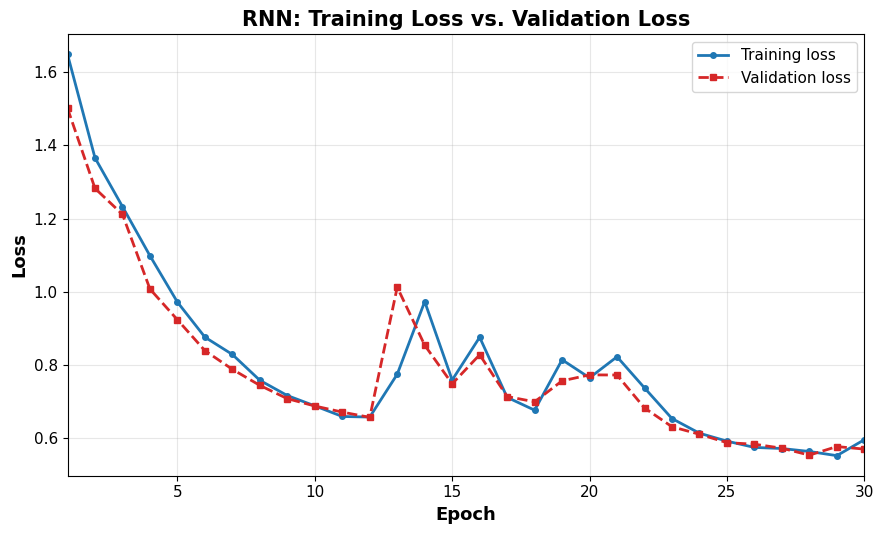

[saved] /kaggle/working/experiment6_part1_outputs/plots/02_rnn_loss.png


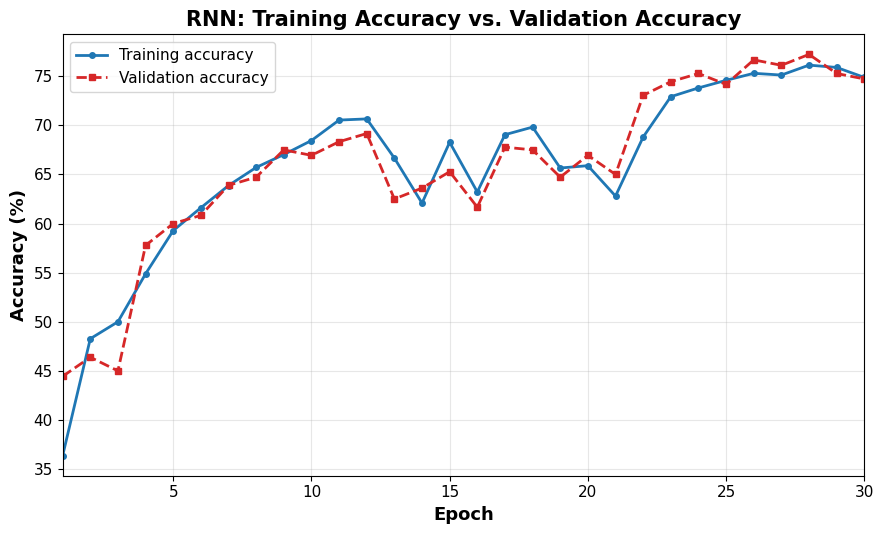

[saved] /kaggle/working/experiment6_part1_outputs/plots/03_rnn_accuracy.png


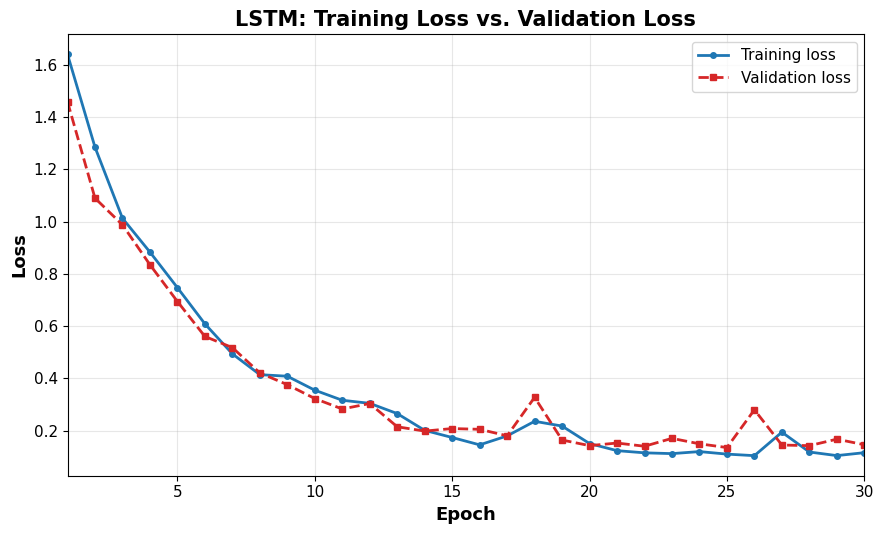

[saved] /kaggle/working/experiment6_part1_outputs/plots/04_lstm_loss.png


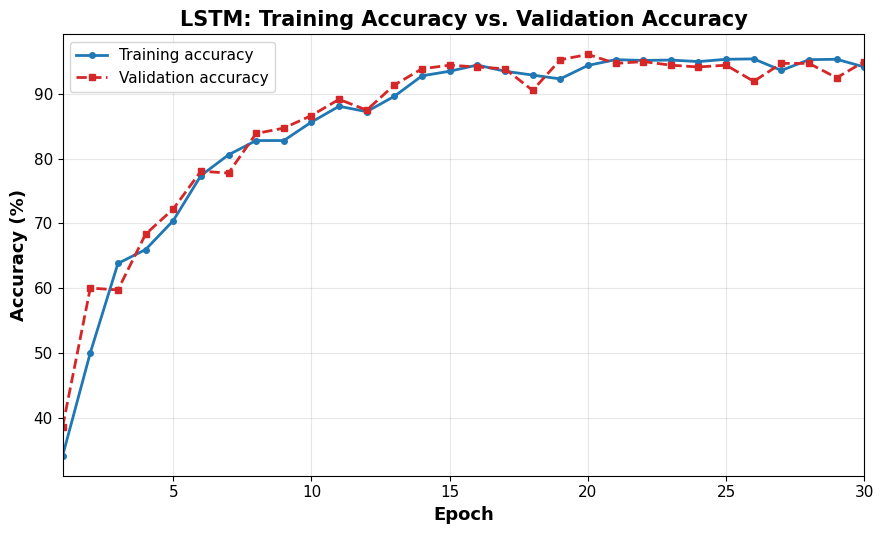

[saved] /kaggle/working/experiment6_part1_outputs/plots/05_lstm_accuracy.png


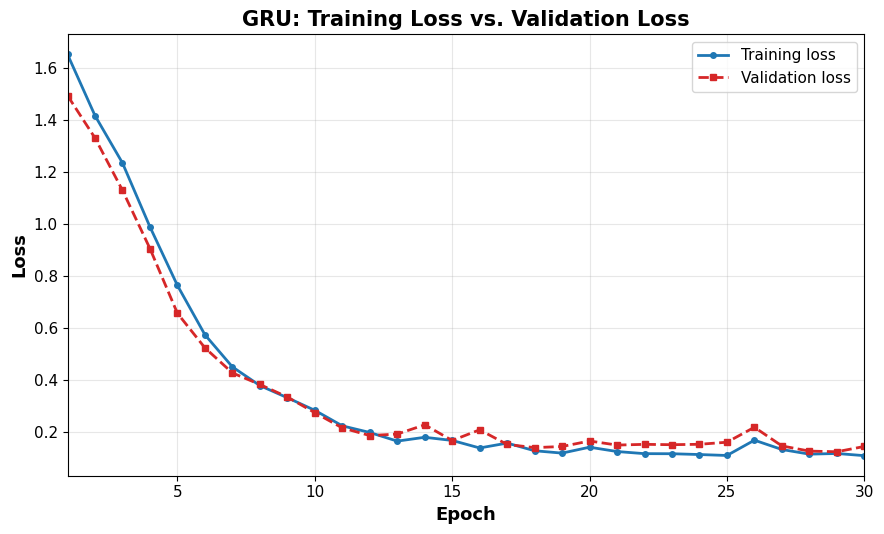

[saved] /kaggle/working/experiment6_part1_outputs/plots/06_gru_loss.png


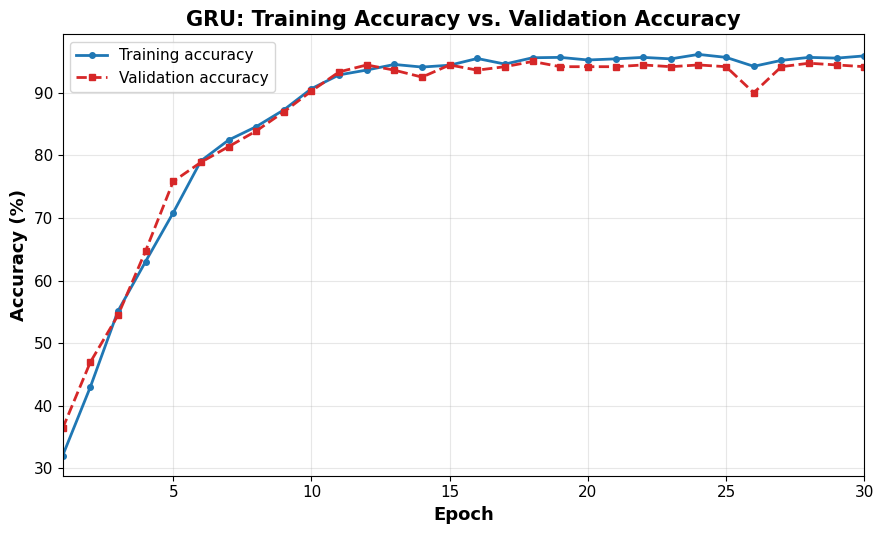

[saved] /kaggle/working/experiment6_part1_outputs/plots/07_gru_accuracy.png


In [18]:
CURVE_FILES = {("RNN", "loss"): "02_rnn_loss.png", ("RNN", "accuracy"): "03_rnn_accuracy.png",
               ("LSTM", "loss"): "04_lstm_loss.png", ("LSTM", "accuracy"): "05_lstm_accuracy.png",
               ("GRU", "loss"): "06_gru_loss.png", ("GRU", "accuracy"): "07_gru_accuracy.png"}


def plot_curve(name, metric):
    h = RESULTS[name]["history"]
    epochs = np.arange(1, len(h) + 1)
    scale = 100 if metric == "accuracy" else 1
    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.plot(epochs, h[metric] * scale, "o-", ms=4, lw=2, color="tab:blue", label=f"Training {metric}")
    ax.plot(epochs, h[f"val_{metric}"] * scale, "s--", ms=4, lw=2, color="tab:red", label=f"Validation {metric}")
    if metric == "loss":
        ax.set_title(f"{name}: Training Loss vs. Validation Loss")
        ax.set_ylabel("Loss")
    else:
        ax.set_title(f"{name}: Training Accuracy vs. Validation Accuracy")
        ax.set_ylabel("Accuracy (%)")
    ax.set_xlabel("Epoch")
    ax.set_xlim(1, len(h))
    ax.legend(loc="best")
    save_fig(fig, "plots", CURVE_FILES[(name, metric)])


for name in MODEL_NAMES:
    plot_curve(name, "loss")
    plot_curve(name, "accuracy")

### Automatic training-curve analysis (based only on the measured curves)
Heuristics used (stated explicitly so the conclusions are traceable):
*overfitting* = validation loss ends >10% above its minimum, that minimum occurred ≥5 epochs before the end, and training loss is lower than at that
minimum; *underfitting* = both final training and validation accuracy < 70%; *plateau* = training loss changed by less than 5% over the last 5 epochs.
Note: Keras training metrics are averaged over the epoch **with dropout active**, so training accuracy can be slightly below validation accuracy.

In [19]:
def analyze_training_curves(name, h):
    n = len(h)
    tl, vl = h["loss"].values, h["val_loss"].values
    ta, va = h["accuracy"].values * 100, h["val_accuracy"].values * 100
    k = min(5, n)
    best_ep = int(np.argmin(vl)) + 1
    train_drop = (tl[0] - tl[-1]) / tl[0] * 100
    late_train_change = (tl[-1] - tl[-k]) / tl[-k] * 100
    late_val_change = (vl[-1] - vl[-k]) / vl[-k] * 100
    val_rise = (vl[-1] - vl.min()) / vl.min() * 100
    acc_gap, loss_gap = ta[-1] - va[-1], vl[-1] - tl[-1]
    ep_within_1pp = int(np.argmax(va >= va.max() - 1.0)) + 1
    noise = np.mean(np.abs(np.diff(vl[-10:]))) / np.mean(vl[-10:]) * 100 if n > 2 else 0.0
    overfit = bool(val_rise > 10 and best_ep <= n - 5 and tl[-1] < tl[best_ep - 1])
    underfit = bool(ta[-1] < 70 and va[-1] < 70)
    plateau = bool(late_train_change > -5)

    emit(f"--- {name} ---")
    emit(f"Convergence: training loss fell from {tl[0]:.3f} (epoch 1) to {tl[-1]:.3f} (epoch {n}), a {train_drop:.1f}% reduction; "
         f"over the last {k} epochs it changed by {late_train_change:+.1f}% -> "
         + ("it has flattened (largely converged)." if plateau else "it was still decreasing appreciably (not fully converged in the epoch budget)."))
    emit(f"Validation: minimum validation loss {vl.min():.3f} at epoch {best_ep}; final validation loss {vl[-1]:.3f} "
         f"({val_rise:+.1f}% relative to the minimum; {late_val_change:+.1f}% over the last {k} epochs). "
         f"Validation accuracy first came within 1 pp of its best ({va.max():.1f}%) at epoch {ep_within_1pp}.")
    emit(f"Stability: mean epoch-to-epoch change of validation loss over the last 10 epochs = {noise:.1f}% of its mean -> "
         + ("fairly noisy validation curve." if noise > 10 else "relatively smooth validation curve."))
    emit(f"Generalization gap (final epoch): train acc {ta[-1]:.1f}% vs val acc {va[-1]:.1f}% (gap {acc_gap:+.1f} pp); "
         f"val loss - train loss = {loss_gap:+.3f}.")
    if overfit:
        emit("Overfitting: SUPPORTED by the curves (validation loss rose while training loss kept falling).")
    else:
        emit("Overfitting: NOT clearly supported (validation loss did not rise markedly above its minimum while training loss improved).")
    if underfit:
        emit("Underfitting: SUPPORTED (both training and validation accuracy remain below 70%).")
    else:
        emit(f"Underfitting: NOT supported (final training accuracy {ta[-1]:.1f}%, validation accuracy {va[-1]:.1f}%).")
    if acc_gap < 0:
        emit("Note: validation accuracy exceeds training accuracy, consistent with dropout being active only during training.")
    emit()
    return {"n": n, "best_ep": best_ep, "plateau": plateau, "overfit": overfit, "underfit": underfit, "acc_gap": acc_gap,
            "loss_gap": loss_gap, "train_drop": train_drop, "final_tl": tl[-1], "final_vl": vl[-1], "final_ta": ta[-1],
            "final_va": va[-1], "ep_within_1pp": ep_within_1pp, "noise": noise, "val_rise": val_rise}


emit("=== AUTOMATIC TRAINING-CURVE ANALYSIS ===")
curve_info = {name: analyze_training_curves(name, RESULTS[name]["history"]) for name in MODEL_NAMES}

=== AUTOMATIC TRAINING-CURVE ANALYSIS ===
--- RNN ---
Convergence: training loss fell from 1.648 (epoch 1) to 0.596 (epoch 30), a 63.8% reduction; over the last 5 epochs it changed by +3.7% -> it has flattened (largely converged).
Validation: minimum validation loss 0.554 at epoch 28; final validation loss 0.571 (+3.0% relative to the minimum; -2.3% over the last 5 epochs). Validation accuracy first came within 1 pp of its best (77.2%) at epoch 26.
Stability: mean epoch-to-epoch change of validation loss over the last 10 epochs = 4.5% of its mean -> relatively smooth validation curve.
Generalization gap (final epoch): train acc 74.9% vs val acc 74.7% (gap +0.2 pp); val loss - train loss = -0.026.
Overfitting: NOT clearly supported (validation loss did not rise markedly above its minimum while training loss improved).
Underfitting: NOT supported (final training accuracy 74.9%, validation accuracy 74.7%).

--- LSTM ---
Convergence: training loss fell from 1.640 (epoch 1) to 0.116 (epoch 

## 17. Test Evaluation
The independent test set (360 windows, official test subjects) is used **once**, now that all models are trained.

In [20]:
for name in MODEL_NAMES:
    metrics, y_pred = evaluate_model(MODELS[name], X_test, y_test)
    RESULTS[name].update({"test_metrics": metrics, "y_pred": y_pred,
                          "cm": confusion_matrix(y_test, y_pred, labels=list(range(N_CLASSES)))})
    report = classification_report(y_test, y_pred, target_names=ACTIVITY_NAMES, digits=4, zero_division=0)
    (DIRS["model_results"] / f"{name.lower()}_classification_report.txt").write_text(report)
    save_table(pd.DataFrame({"y_true": y_test, "y_pred": y_pred}), "model_results", f"{name.lower()}_test_predictions.csv")
    print(f"\n{name} test classification report (per class):\n{report}")

comparison_df = pd.DataFrame([{
    "Model": n,
    "Accuracy (%)": RESULTS[n]["test_metrics"]["accuracy"],
    "Macro Precision (%)": RESULTS[n]["test_metrics"]["precision"],
    "Macro Recall (%)": RESULTS[n]["test_metrics"]["recall"],
    "Macro F1 (%)": RESULTS[n]["test_metrics"]["f1"],
    "Parameters": RESULTS[n]["params"],
    "Training Time (s)": RESULTS[n]["train_time"]} for n in MODEL_NAMES])
display(comparison_df.style.format({"Accuracy (%)": "{:.2f}", "Macro Precision (%)": "{:.2f}", "Macro Recall (%)": "{:.2f}",
                                    "Macro F1 (%)": "{:.2f}", "Parameters": "{:,d}", "Training Time (s)": "{:.2f}"})
        .hide(axis="index"))
save_table(comparison_df.round(4), "tables", "05_test_performance_comparison.csv")

[saved] /kaggle/working/experiment6_part1_outputs/model_results/rnn_test_predictions.csv

RNN test classification report (per class):
                    precision    recall  f1-score   support

           WALKING     0.5783    0.8000    0.6713        60
  WALKING_UPSTAIRS     0.6923    0.6000    0.6429        60
WALKING_DOWNSTAIRS     0.8085    0.6333    0.7103        60
           SITTING     0.8065    0.8333    0.8197        60
          STANDING     0.8571    0.8000    0.8276        60
            LAYING     1.0000    1.0000    1.0000        60

          accuracy                         0.7778       360
         macro avg     0.7905    0.7778    0.7786       360
      weighted avg     0.7905    0.7778    0.7786       360

[saved] /kaggle/working/experiment6_part1_outputs/model_results/lstm_test_predictions.csv

LSTM test classification report (per class):
                    precision    recall  f1-score   support

           WALKING     0.8923    0.9667    0.9280        60
  WALK

Model,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
RNN,77.78,79.05,77.78,77.86,"1,974",24.23
LSTM,90.83,91.06,90.83,90.80,"6,006",21.44
GRU,91.67,91.82,91.67,91.61,"4,758",18.05


[saved] /kaggle/working/experiment6_part1_outputs/tables/05_test_performance_comparison.csv


## 18. Confusion Matrices (Plot 4)

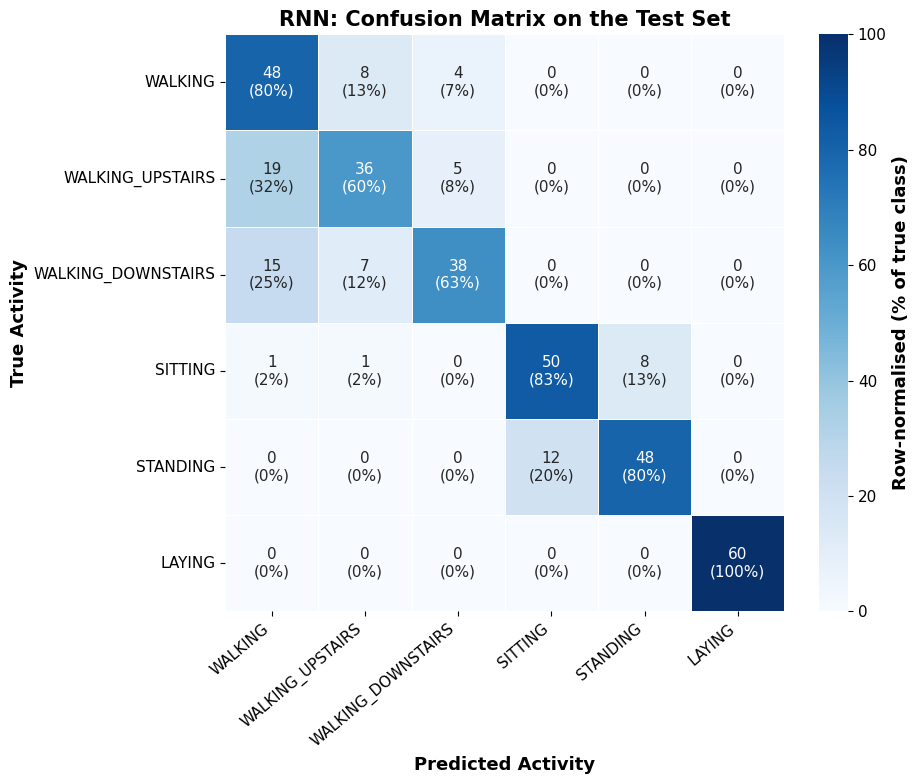

[saved] /kaggle/working/experiment6_part1_outputs/confusion_matrices/08_rnn_confusion_matrix.png
[saved] /kaggle/working/experiment6_part1_outputs/confusion_matrices/rnn_confusion_matrix_counts.csv


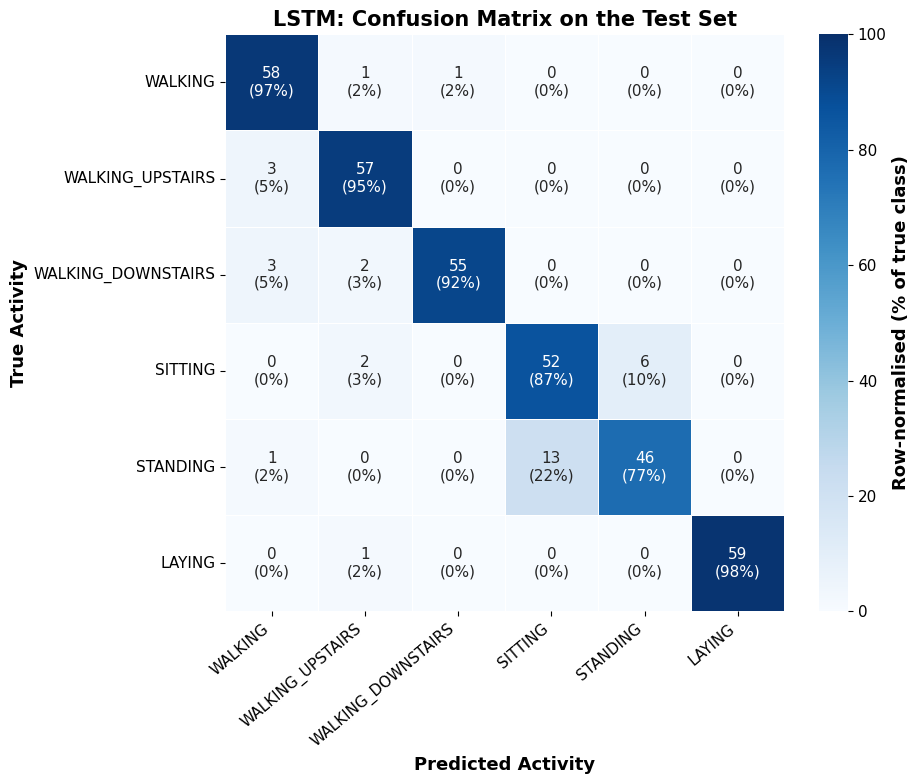

[saved] /kaggle/working/experiment6_part1_outputs/confusion_matrices/09_lstm_confusion_matrix.png
[saved] /kaggle/working/experiment6_part1_outputs/confusion_matrices/lstm_confusion_matrix_counts.csv


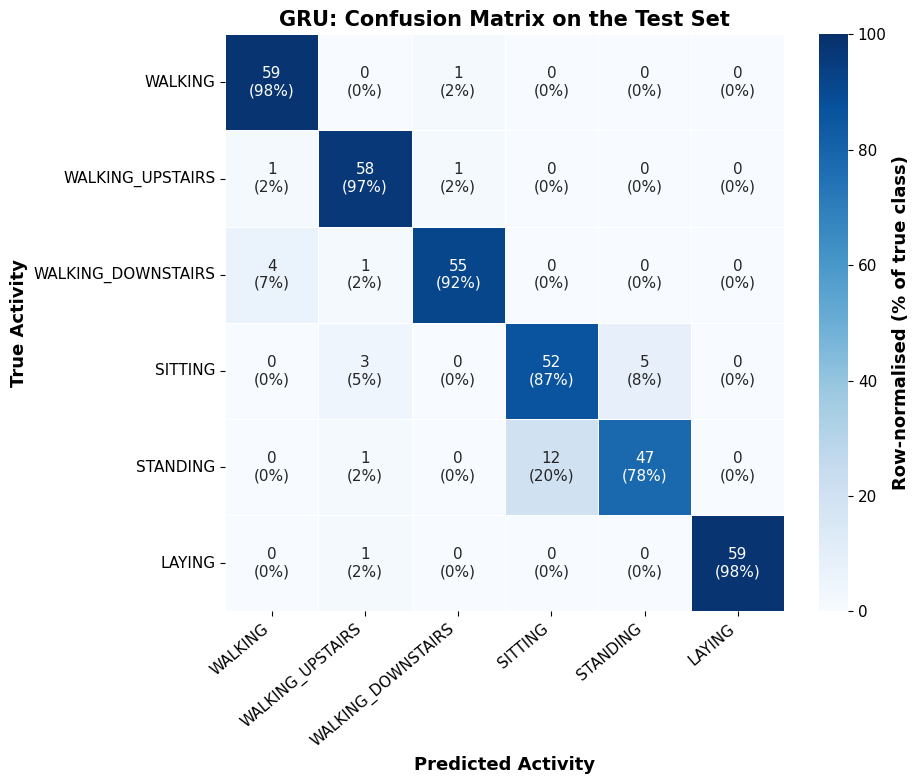

[saved] /kaggle/working/experiment6_part1_outputs/confusion_matrices/10_gru_confusion_matrix.png
[saved] /kaggle/working/experiment6_part1_outputs/confusion_matrices/gru_confusion_matrix_counts.csv


In [21]:
CM_FILES = {"RNN": "08_rnn_confusion_matrix.png", "LSTM": "09_lstm_confusion_matrix.png", "GRU": "10_gru_confusion_matrix.png"}


def plot_confusion(name):
    cm = RESULTS[name]["cm"]
    row_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    annot = np.array([[f"{cm[i, j]}\n({row_pct[i, j]:.0f}%)" for j in range(N_CLASSES)] for i in range(N_CLASSES)])
    fig, ax = plt.subplots(figsize=(9.5, 8))
    sns.heatmap(row_pct, annot=annot, fmt="", cmap="Blues", vmin=0, vmax=100, linewidths=0.5, linecolor="white",
                xticklabels=ACTIVITY_NAMES, yticklabels=ACTIVITY_NAMES, annot_kws={"fontsize": 11},
                cbar_kws={"label": "Row-normalised (% of true class)"}, ax=ax)
    ax.grid(False)
    ax.set_title(f"{name}: Confusion Matrix on the Test Set")
    ax.set_xlabel("Predicted Activity")
    ax.set_ylabel("True Activity")
    ax.tick_params(axis="x", rotation=40)
    plt.setp(ax.get_xticklabels(), ha="right")
    ax.tick_params(axis="y", rotation=0)
    ax.collections[0].colorbar.ax.yaxis.label.set_fontweight("bold")
    save_fig(fig, "confusion_matrices", CM_FILES[name])


for name in MODEL_NAMES:
    plot_confusion(name)
    save_table(pd.DataFrame(RESULTS[name]["cm"], index=ACTIVITY_NAMES, columns=ACTIVITY_NAMES), "confusion_matrices",
               f"{name.lower()}_confusion_matrix_counts.csv", index=True)

### Automatic confusion-matrix analysis (determined from the actual matrices)

In [22]:
def analyze_confusions(results):
    info = {}
    emit("=== AUTOMATIC CONFUSION-MATRIX ANALYSIS ===")
    for name in MODEL_NAMES:
        cm = results[name]["cm"]
        support, correct = cm.sum(axis=1), np.diag(cm)
        recall = correct / support
        errors = support - correct
        best = [ACTIVITY_NAMES[i] for i in np.where(np.isclose(recall, recall.max()))[0]]
        worst = [ACTIVITY_NAMES[i] for i in np.where(errors == errors.max())[0]]
        pairs = sorted([(cm[i, j] + cm[j, i], i, j, cm[i, j], cm[j, i]) for i in range(N_CLASSES) for j in range(i + 1, N_CLASSES)],
                       reverse=True)
        top_pairs = [p for p in pairs if p[0] > 0][:3]
        info[name] = {"recall": recall, "best": best, "worst": worst, "errors": errors, "top_pairs": top_pairs}
        emit(f"--- {name} ---")
        emit("Per-class recognition rate: " + ", ".join(f"{ACTIVITY_NAMES[i]} {recall[i]*100:.1f}%" for i in range(N_CLASSES)))
        emit(f"1) Highest recognition rate: {', '.join(best)} ({recall.max()*100:.1f}%).")
        emit(f"2) Largest number of misclassifications (errors among that class's true samples): {', '.join(worst)} "
             f"({int(errors.max())} of {int(support[np.where(errors == errors.max())[0][0]])} windows).")
        if top_pairs:
            emit("3) Most frequently confused pairs: " + "; ".join(
                f"{ACTIVITY_NAMES[i]} <-> {ACTIVITY_NAMES[j]} ({tot} errors: {a} true {ACTIVITY_NAMES[i]} predicted as {ACTIVITY_NAMES[j]}, {b} true {ACTIVITY_NAMES[j]} predicted as {ACTIVITY_NAMES[i]})"
                for tot, i, j, a, b in top_pairs))
        else:
            emit("3) No confusions between classes (perfect classification).")
    # Consistency across models
    top_sets = {n: {(p[1], p[2]) for p in info[n]["top_pairs"]} for n in MODEL_NAMES}
    common = set.intersection(*top_sets.values()) if all(top_sets.values()) else set()
    same_best = len({tuple(info[n]["best"]) for n in MODEL_NAMES}) == 1
    same_worst = len({tuple(info[n]["worst"]) for n in MODEL_NAMES}) == 1
    emit("--- Consistency across RNN / LSTM / GRU ---")
    emit("4) Best-recognised activity is " + ("the same for all three models." if same_best else "NOT the same for all three models: "
         + "; ".join(f"{n}: {', '.join(info[n]['best'])}" for n in MODEL_NAMES)))
    emit("   Activity with most misclassifications is " + ("the same for all three models." if same_worst else "NOT the same for all three models: "
         + "; ".join(f"{n}: {', '.join(info[n]['worst'])}" for n in MODEL_NAMES)))
    if common:
        emit("   Confused pair(s) present in the top-3 of ALL three models: " + ", ".join(f"{ACTIVITY_NAMES[i]} <-> {ACTIVITY_NAMES[j]}" for i, j in common))
    else:
        emit("   No confused pair appears in the top-3 of all three models.")
    emit()
    info["common_pairs"] = [(ACTIVITY_NAMES[i], ACTIVITY_NAMES[j]) for i, j in common]
    info["same_best"], info["same_worst"] = same_best, same_worst
    return info


conf_info = analyze_confusions(RESULTS)

=== AUTOMATIC CONFUSION-MATRIX ANALYSIS ===
--- RNN ---
Per-class recognition rate: WALKING 80.0%, WALKING_UPSTAIRS 60.0%, WALKING_DOWNSTAIRS 63.3%, SITTING 83.3%, STANDING 80.0%, LAYING 100.0%
1) Highest recognition rate: LAYING (100.0%).
2) Largest number of misclassifications (errors among that class's true samples): WALKING_UPSTAIRS (24 of 60 windows).
3) Most frequently confused pairs: WALKING <-> WALKING_UPSTAIRS (27 errors: 8 true WALKING predicted as WALKING_UPSTAIRS, 19 true WALKING_UPSTAIRS predicted as WALKING); SITTING <-> STANDING (20 errors: 8 true SITTING predicted as STANDING, 12 true STANDING predicted as SITTING); WALKING <-> WALKING_DOWNSTAIRS (19 errors: 4 true WALKING predicted as WALKING_DOWNSTAIRS, 15 true WALKING_DOWNSTAIRS predicted as WALKING)
--- LSTM ---
Per-class recognition rate: WALKING 96.7%, WALKING_UPSTAIRS 95.0%, WALKING_DOWNSTAIRS 91.7%, SITTING 86.7%, STANDING 76.7%, LAYING 98.3%
1) Highest recognition rate: LAYING (98.3%).
2) Largest number of misc

## 19. RNN vs LSTM vs GRU Comparison (Architecture Table, Plot 5 and Pipeline Diagrams)

In [23]:
gate_props = ["Hidden state", "Cell state", "Forget gate", "Input gate", "Output gate", "Update gate", "Reset gate"]
gate_values = {"RNN": ["Yes", "No", "No", "No", "No", "No", "No"],
               "LSTM": ["Yes", "Yes", "Yes", "Yes", "Yes", "No", "No"],
               "GRU": ["Yes", "No", "No", "No", "No", "Yes", "Yes"]}
measured_props = ["Recurrent-layer parameters", "Total trainable parameters", "Training time (s)", "Test F1-score (%)"]
arch_df = pd.DataFrame({"Property": gate_props + measured_props})
for name in MODEL_NAMES:   # architectural Yes/No + MEASURED values
    arch_df[name] = gate_values[name] + [
        f"{MODELS[name].get_layer(name.lower() + '_layer').count_params():,}",
        f"{RESULTS[name]['params']:,}",
        f"{RESULTS[name]['train_time']:.2f}",
        f"{RESULTS[name]['test_metrics']['f1']:.2f}"]
display(arch_df)
save_table(arch_df, "tables", "06_architecture_comparison.csv")

emit("=== WHY LSTM AND GRU HAVE DIFFERENT COMPLEXITY FROM THE VANILLA RNN ===")
emit(f"A vanilla RNN has ONE set of weights (input->hidden, hidden->hidden, bias): {F}x{U} + {U}x{U} + {U} = {expected_rec['RNN']} parameters. "
     f"An LSTM computes four transformations (forget, input, output gates and the candidate cell state), i.e. 4x the RNN weight sets = "
     f"{expected_rec['LSTM']} parameters. A GRU computes three (update gate, reset gate and candidate state) = {expected_rec['GRU']} parameters "
     f"(Keras' default reset_after=True uses two bias vectors). These formulas match the counts reported by Keras above. "
     f"The extra parameters buy multiplicative gates (and, for the LSTM, a separate cell state) that control what is kept or discarded across time steps; "
     f"the GRU merges cell and hidden state and uses fewer gates, so it sits between the RNN and the LSTM in size.")
emit()

,Property,RNN,LSTM,GRU
0,Hidden state,Yes,Yes,Yes
1,Cell state,No,Yes,No
2,Forget gate,No,Yes,No
3,Input gate,No,Yes,No
4,Output gate,No,Yes,No
5,Update gate,No,No,Yes
6,Reset gate,No,No,Yes
7,Recurrent-layer parameters,"1,344","5,376","4,128"
8,Total trainable parameters,"1,974","6,006","4,758"
9,Training time (s),24.23,21.44,18.05


[saved] /kaggle/working/experiment6_part1_outputs/tables/06_architecture_comparison.csv
=== WHY LSTM AND GRU HAVE DIFFERENT COMPLEXITY FROM THE VANILLA RNN ===
A vanilla RNN has ONE set of weights (input->hidden, hidden->hidden, bias): 9x32 + 32x32 + 32 = 1344 parameters. An LSTM computes four transformations (forget, input, output gates and the candidate cell state), i.e. 4x the RNN weight sets = 5376 parameters. A GRU computes three (update gate, reset gate and candidate state) = 4128 parameters (Keras' default reset_after=True uses two bias vectors). These formulas match the counts reported by Keras above. The extra parameters buy multiplicative gates (and, for the LSTM, a separate cell state) that control what is kept or discarded across time steps; the GRU merges cell and hidden state and uses fewer gates, so it sits between the RNN and the LSTM in size.



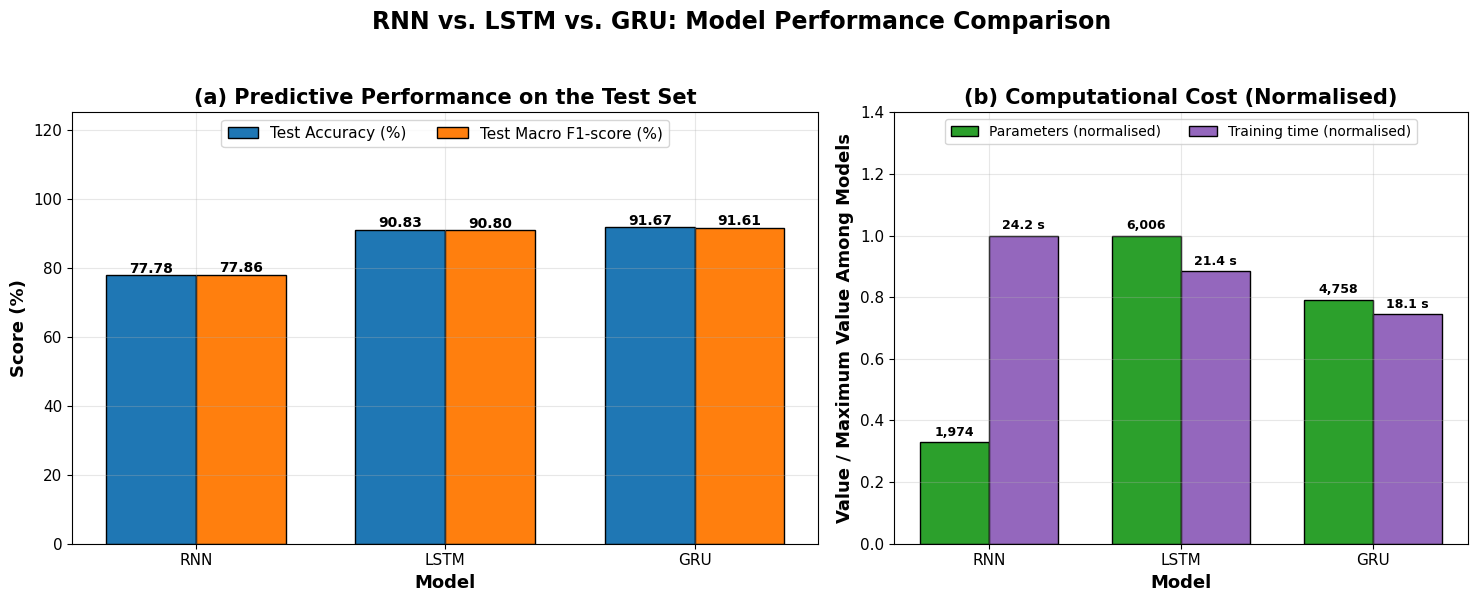

[saved] /kaggle/working/experiment6_part1_outputs/plots/11_model_performance_comparison.png


In [24]:
# Plot 5: predictive performance (left) is kept separate from normalised computational measures (right)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1.3, 1]})
xpos, bar_w = np.arange(len(MODEL_NAMES)), 0.36
acc_vals = comparison_df["Accuracy (%)"].values
f1_vals = comparison_df["Macro F1 (%)"].values
b1 = ax1.bar(xpos - bar_w / 2, acc_vals, bar_w, label="Test Accuracy (%)", color="tab:blue", edgecolor="black")
b2 = ax1.bar(xpos + bar_w / 2, f1_vals, bar_w, label="Test Macro F1-score (%)", color="tab:orange", edgecolor="black")
for bars in (b1, b2):
    for bar in bars:
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8, f"{bar.get_height():.2f}", ha="center", fontsize=10, fontweight="bold")
ax1.set_xticks(xpos)
ax1.set_xticklabels(MODEL_NAMES)
ax1.set_ylim(0, 125)
ax1.set_xlabel("Model")
ax1.set_ylabel("Score (%)")
ax1.set_title("(a) Predictive Performance on the Test Set")
ax1.legend(loc="upper center", ncol=2)

params_arr = comparison_df["Parameters"].values.astype(float)
time_arr = comparison_df["Training Time (s)"].values.astype(float)
c1 = ax2.bar(xpos - bar_w / 2, params_arr / params_arr.max(), bar_w, label="Parameters (normalised)", color="tab:green", edgecolor="black")
c2 = ax2.bar(xpos + bar_w / 2, time_arr / time_arr.max(), bar_w, label="Training time (normalised)", color="tab:purple", edgecolor="black")
for bar, val in zip(c1, params_arr):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f"{int(val):,}", ha="center", fontsize=9, fontweight="bold")
for bar, val in zip(c2, time_arr):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f"{val:.1f} s", ha="center", fontsize=9, fontweight="bold")
ax2.set_xticks(xpos)
ax2.set_xticklabels(MODEL_NAMES)
ax2.set_ylim(0, 1.4)
ax2.set_xlabel("Model")
ax2.set_ylabel("Value / Maximum Value Among Models")
ax2.set_title("(b) Computational Cost (Normalised)")
ax2.legend(loc="upper center", ncol=2, fontsize=10)
fig.suptitle("RNN vs. LSTM vs. GRU: Model Performance Comparison", fontsize=17, y=1.0)
fig.tight_layout(rect=[0, 0, 1, 0.97])
save_fig(fig, "plots", "11_model_performance_comparison.png", tight=False)

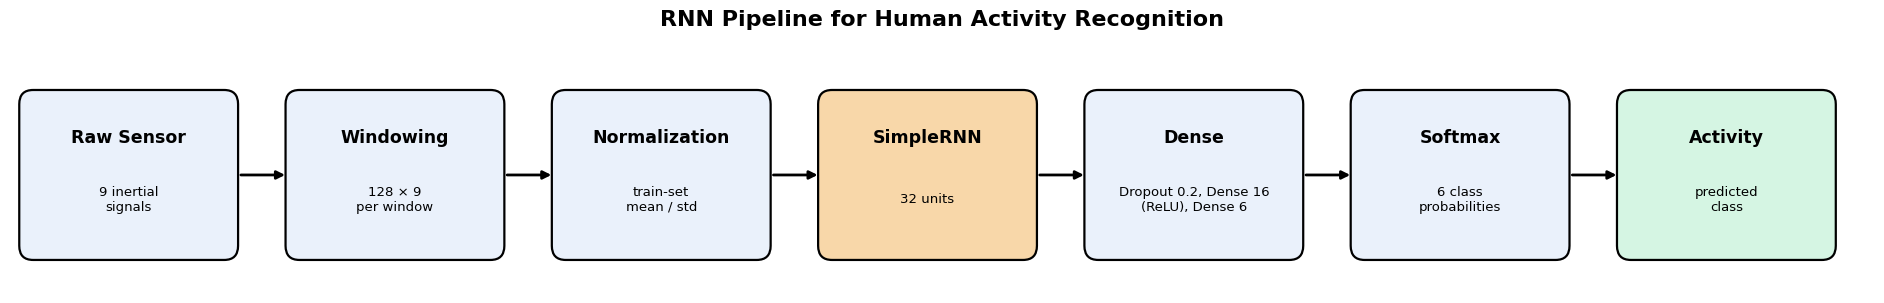

[saved] /kaggle/working/experiment6_part1_outputs/diagrams/13_rnn_pipeline_diagram.png


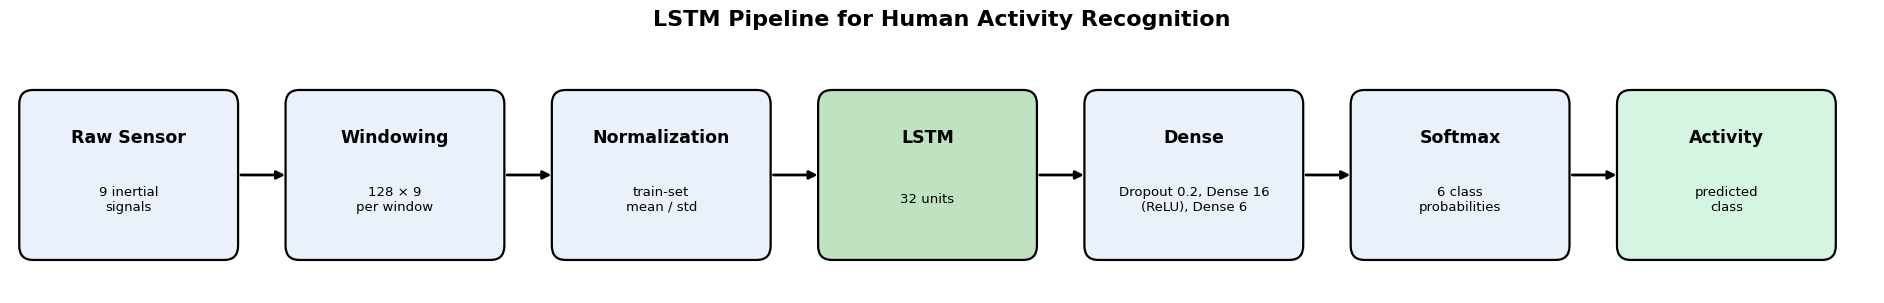

[saved] /kaggle/working/experiment6_part1_outputs/diagrams/14_lstm_pipeline_diagram.png


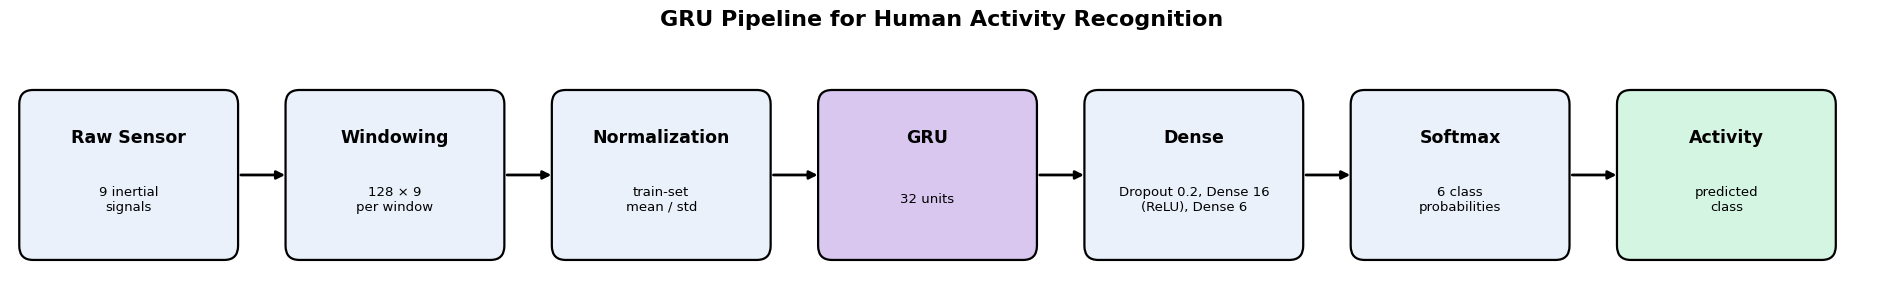

[saved] /kaggle/working/experiment6_part1_outputs/diagrams/15_gru_pipeline_diagram.png


In [25]:
# Pipeline (architecture) diagrams for RNN / LSTM / GRU
def draw_pipeline(model_name, rec_label, filename, rec_color):
    stages = [("Raw Sensor", "9 inertial\nsignals"), ("Windowing", "128 × 9\nper window"), ("Normalization", "train-set\nmean / std"),
              (rec_label, f"{UNITS} units"), ("Dense", "Dropout 0.2, Dense 16\n(ReLU), Dense 6"),
              ("Softmax", "6 class\nprobabilities"), ("Activity", "predicted\nclass")]
    step = 2.3
    fig, ax = plt.subplots(figsize=(19, 3.2))
    ax.set_xlim(0, len(stages) * step)
    ax.set_ylim(0.5, 2.7)
    ax.axis("off")
    for i, (title, sub) in enumerate(stages):
        x = i * step + 0.1
        face = rec_color if i == 3 else ("#D5F5E3" if i == len(stages) - 1 else "#EAF1FB")
        ax.add_patch(FancyBboxPatch((x, 0.8), 1.85, 1.4, boxstyle="round,pad=0.02,rounding_size=0.12", fc=face, ec="black", lw=1.6))
        ax.text(x + 0.925, 1.82, title, ha="center", va="center", fontsize=12.5, fontweight="bold")
        ax.text(x + 0.925, 1.3, sub, ha="center", va="center", fontsize=9.5)
        if i < len(stages) - 1:
            ax.annotate("", xy=(x + step, 1.5), xytext=(x + 1.87, 1.5), arrowprops=dict(arrowstyle="-|>", lw=2, color="black"))
    ax.set_title(f"{model_name} Pipeline for Human Activity Recognition", fontsize=16, fontweight="bold", pad=6)
    save_fig(fig, "diagrams", filename)


draw_pipeline("RNN", "SimpleRNN", "13_rnn_pipeline_diagram.png", "#F8D7A9")
draw_pipeline("LSTM", "LSTM", "14_lstm_pipeline_diagram.png", "#BFE3C0")
draw_pipeline("GRU", "GRU", "15_gru_pipeline_diagram.png", "#D9C7F0")

## 20. Effect of Sequence Length (Plot 6)
The **same** methodology is applied for T = 32, 64 and 128: the *first T time steps* of every (already normalised) window are kept
(consistent truncation, same normalisation statistics, same split, same models/hyper-parameters, fresh weights with the same seed).
The T = 128 entry re-uses the main experiment above (identical function/protocol), which avoids re-training the same configuration twice.
At 50 Hz, T = 32 / 64 / 128 correspond to 0.64 s / 1.28 s / 2.56 s of motion.

In [26]:
seq_rows = []
for T in SEQ_LENGTHS:
    for name in MODEL_NAMES:
        if T == SEQ_LEN:                                           # re-use main experiment (same protocol)
            r = RESULTS[name]
            seq_rows.append({"Sequence Length": T, "Model": name, "Accuracy (%)": r["test_metrics"]["accuracy"],
                             "Macro F1 (%)": r["test_metrics"]["f1"], "Training Time (s)": r["train_time"], "Parameters": r["params"]})
            continue
        print(f"\n=== {name} with T = {T} ===")
        model_T = build_model(name, T)
        hist_T, time_T = train_model(model_T, f"{name}-T{T}", X_train[:, :T, :], y_train, X_val[:, :T, :], y_val)
        metrics_T, _ = evaluate_model(model_T, X_test[:, :T, :], y_test)
        seq_rows.append({"Sequence Length": T, "Model": name, "Accuracy (%)": metrics_T["accuracy"],
                         "Macro F1 (%)": metrics_T["f1"], "Training Time (s)": time_T, "Parameters": trainable_params(model_T)})
        print(f"  {name}, T={T}: test macro-F1 = {metrics_T['f1']:.2f}%  (train time {time_T:.1f} s)")

seq_long = pd.DataFrame(seq_rows)
save_table(seq_long.round(4), "tables", "07_sequence_length_detailed_results.csv")
seq_df = seq_long.pivot(index="Sequence Length", columns="Model", values="Macro F1 (%)")[MODEL_NAMES].reset_index()
seq_df.columns = ["Sequence Length", "RNN F1", "LSTM F1", "GRU F1"]
display(seq_df.style.format({"RNN F1": "{:.2f}", "LSTM F1": "{:.2f}", "GRU F1": "{:.2f}"}).hide(axis="index"))
save_table(seq_df.round(4), "tables", "08_sequence_length_vs_f1.csv")


=== RNN with T = 32 ===
  [RNN-T32] epoch  1/30 | loss 1.6470 acc 0.3613 | val_loss 1.3887 val_acc 0.5139
  [RNN-T32] epoch  5/30 | loss 0.8663 acc 0.6387 | val_loss 0.8483 val_acc 0.6222
  [RNN-T32] epoch 10/30 | loss 0.7120 acc 0.6685 | val_loss 0.7153 val_acc 0.6722
  [RNN-T32] epoch 15/30 | loss 0.6162 acc 0.7280 | val_loss 0.6332 val_acc 0.7278
  [RNN-T32] epoch 20/30 | loss 0.5545 acc 0.7673 | val_loss 0.5894 val_acc 0.7528
  [RNN-T32] epoch 25/30 | loss 0.5132 acc 0.7845 | val_loss 0.5349 val_acc 0.7778
  [RNN-T32] epoch 30/30 | loss 0.4856 acc 0.7923 | val_loss 0.5297 val_acc 0.7889
  RNN, T=32: test macro-F1 = 73.98%  (train time 17.2 s)

=== LSTM with T = 32 ===
  [LSTM-T32] epoch  1/30 | loss 1.6485 acc 0.3446 | val_loss 1.4563 val_acc 0.4167
  [LSTM-T32] epoch  5/30 | loss 0.6743 acc 0.7381 | val_loss 0.6036 val_acc 0.7500
  [LSTM-T32] epoch 10/30 | loss 0.3379 acc 0.8732 | val_loss 0.3988 val_acc 0.8444
  [LSTM-T32] epoch 15/30 | loss 0.2241 acc 0.9196 | val_loss 0.2813 v

Sequence Length,RNN F1,LSTM F1,GRU F1
32,73.98,87.49,91.38
64,74.54,90.52,92.46
128,77.86,90.80,91.61


[saved] /kaggle/working/experiment6_part1_outputs/tables/08_sequence_length_vs_f1.csv


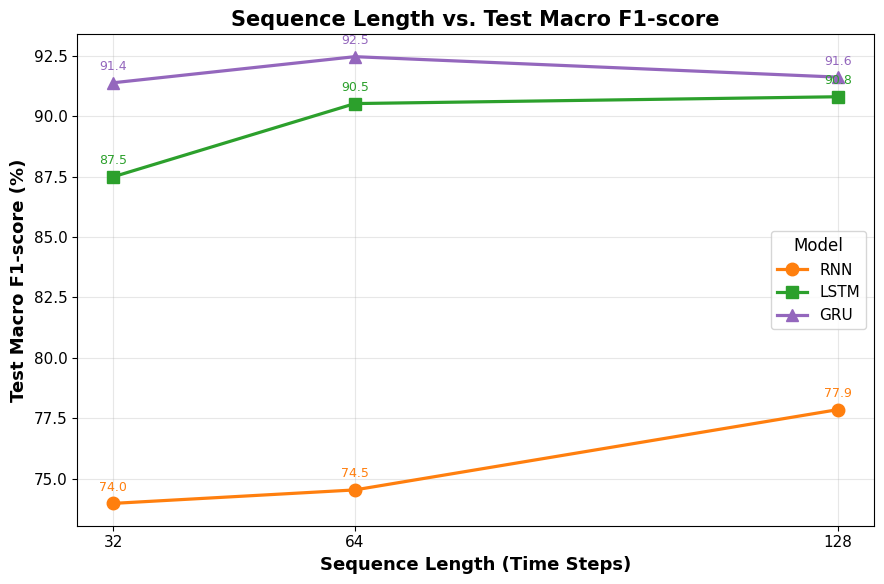

[saved] /kaggle/working/experiment6_part1_outputs/plots/12_sequence_length_vs_f1.png


In [27]:
fig, ax = plt.subplots(figsize=(9, 6))
for name, marker, color in zip(MODEL_NAMES, ["o", "s", "^"], ["tab:orange", "tab:green", "tab:purple"]):
    ax.plot(seq_df["Sequence Length"], seq_df[f"{name} F1"], marker=marker, ms=9, lw=2.3, color=color, label=name)
    for xv, yv in zip(seq_df["Sequence Length"], seq_df[f"{name} F1"]):
        ax.annotate(f"{yv:.1f}", (xv, yv), textcoords="offset points", xytext=(0, 9), ha="center", fontsize=9, color=color)
ax.set_xticks(SEQ_LENGTHS)
ax.set_xlabel("Sequence Length (Time Steps)")
ax.set_ylabel("Test Macro F1-score (%)")
ax.set_title("Sequence Length vs. Test Macro F1-score")
ax.legend(title="Model", loc="best")
save_fig(fig, "plots", "12_sequence_length_vs_f1.png")

## 21. Required Inferences / Conclusions
All statements below are generated from the numbers measured in this run.

### 21a. Why does the order of measurements matter? (empirical check on the VALIDATION set)
The already-trained models are re-evaluated on validation windows whose 128 time steps are randomly permuted (independently for each window,
all 9 channels permuted together). No retraining and no test data are involved. A drop in macro-F1 shows that the models use temporal order,
not only the set of sensor values.

In [28]:
shuffle_rng = np.random.default_rng(SEED)
perm = np.argsort(shuffle_rng.random((len(X_val), SEQ_LEN)), axis=1)
X_val_shuffled = np.take_along_axis(X_val, perm[:, :, None], axis=1)

shuffle_rows = []
for name in MODEL_NAMES:
    f1_orig = evaluate_model(MODELS[name], X_val, y_val)[0]["f1"]
    f1_shuf = evaluate_model(MODELS[name], X_val_shuffled, y_val)[0]["f1"]
    shuffle_rows.append({"Model": name, "Val Macro F1 – original order (%)": f1_orig,
                         "Val Macro F1 – shuffled time steps (%)": f1_shuf, "Drop (pp)": f1_orig - f1_shuf})
shuffle_df = pd.DataFrame(shuffle_rows)
shuffle_txt = ", ".join(f"{row['Model']} {-row['Drop (pp)']:+.1f} pp" for _, row in shuffle_df.iterrows())
display(shuffle_df.round(2))
save_table(shuffle_df.round(4), "tables", "09_time_order_shuffle_check_validation.csv")

,Model,Val Macro F1 – original order (%),Val Macro F1 – shuffled time steps (%),Drop (pp)
0,RNN,74.54,70.00,4.54
1,LSTM,94.97,62.58,32.40
2,GRU,94.14,74.07,20.07


[saved] /kaggle/working/experiment6_part1_outputs/tables/09_time_order_shuffle_check_validation.csv


In [32]:
# ---------- helpers for the auto-generated inference text ----------
def infer(title, what, trend, why, conclusion):
    emit(f"### {title}")
    emit(f"  What the plot shows : {what}")
    emit(f"  Trend observed      : {trend}")
    emit(f"  Why it may occur    : {why}")
    emit(f"  Conclusion          : {conclusion}")
    emit()


def trend_word(vals):
    d = np.diff(vals)
    if np.all(d > 0):
        return "increases monotonically"
    if np.all(d < 0):
        return "decreases monotonically"
    return "changes non-monotonically"


res = comparison_df.set_index("Model")
best_f1_model = res["Macro F1 (%)"].idxmax()
f1_spread = res["Macro F1 (%)"].max() - res["Macro F1 (%)"].min()
acc_order = " > ".join(res["Accuracy (%)"].sort_values(ascending=False).index)
time_order = " < ".join(res["Training Time (s)"].sort_values().index)
param_order = " < ".join(res["Parameters"].sort_values().index)
param_rank = list(res["Parameters"].sort_values().index)
time_rank = list(res["Training Time (s)"].sort_values().index)
time_ratio = {n: res.loc[n, "Training Time (s)"] / res.loc["RNN", "Training Time (s)"] for n in MODEL_NAMES}

emit("=" * 90)
emit("REQUIRED INFERENCES (generated from the actual results of this run)")
emit("=" * 90)

# 1. Temporal pattern
ca, cb, cd = temporal_info["closest_pairs"][0]
fa, fb, fd = temporal_info["farthest_pair"]
var_rank = temporal_info["variability_rank"]
infer("1. Temporal pattern in the sensor signals (Plot 01, table 03)",
      "Raw body acceleration, body gyroscope and total acceleration (x-axis) versus time step for one window of each activity.",
      f"Activities with the largest within-window body-acceleration variability are {', '.join(var_rank[:3])}, whereas {', '.join(var_rank[-3:])} show the smallest; "
      f"the mean total-acceleration components of each class are listed in table 03. Most similar pair by the descriptors: {ca} & {cb}; most different pair: {fa} & {fb}.",
      "Walking-type activities involve periodic body motion (repeated steps produce oscillations in acceleration/rotation), while resting postures mainly produce a nearly constant "
      "gravity component whose direction depends on body orientation (this is what separates the postures).",
      "Different activities leave different temporal signatures (oscillation amplitude and gravity orientation). Similar-looking pairs are the ones a classifier is most likely to confuse. "
      "Order matters because the pattern is defined by how values evolve over time. In the validation shuffle check, macro-F1 changed by "
      + shuffle_txt + " when time steps were permuted" + (" -> the models do rely on temporal order." if (shuffle_df["Drop (pp)"] > 5).all()
                                            else " -> the reliance on temporal order is limited or model-dependent in this run."))

# 2-4. Convergence per model
why_conv = {
    "RNN": "A vanilla RNN re-uses one weight matrix across all steps, so BPTT multiplies many Jacobians; gradients can shrink or grow, which may slow or destabilise optimisation on long windows.",
    "LSTM": "The LSTM's gated, additively updated cell state gives gradients a more direct path across time, which can make optimisation easier, at the cost of more parameters.",
    "GRU": "The GRU's update/reset gates give a gated shortcut through time with fewer parameters than the LSTM."}
for i, name in enumerate(MODEL_NAMES, start=2):
    ci = curve_info[name]
    infer(f"{i}. {name} convergence behaviour ({CURVE_FILES[(name, 'loss')]}, {CURVE_FILES[(name, 'accuracy')]})",
          f"Training vs. validation loss and accuracy of the {name} over {ci['n']} epochs.",
          f"Training loss fell by {ci['train_drop']:.1f}% (final {ci['final_tl']:.3f}); validation loss reached its minimum at epoch {ci['best_ep']} and ended at {ci['final_vl']:.3f}; "
          f"final train/val accuracy = {ci['final_ta']:.1f}% / {ci['final_va']:.1f}%; validation accuracy came within 1 pp of its best at epoch {ci['ep_within_1pp']}; "
          f"the training loss {'had flattened' if ci['plateau'] else 'was still decreasing'} at the end.",
          why_conv[name],
          f"Under this fixed budget of {EPOCHS} epochs the {name} " + ("appears largely converged." if ci["plateau"] else "had not fully converged; more epochs could still help.")
          + f" (Single run, seed {SEED}; other seeds may differ.)")

# 5. Over/under-fitting
over = [n for n in MODEL_NAMES if curve_info[n]["overfit"]]
under = [n for n in MODEL_NAMES if curve_info[n]["underfit"]]
infer("5. Evidence of overfitting / underfitting (loss and accuracy curves)",
      "The gap between training and validation curves for each model.",
      "Generalization gap (train acc − val acc, pp): " + ", ".join(f"{n} {curve_info[n]['acc_gap']:+.1f}" for n in MODEL_NAMES)
      + "; validation loss above its minimum at the end: " + ", ".join(f"{n} {curve_info[n]['val_rise']:+.1f}%" for n in MODEL_NAMES) + ".",
      "Overfitting shows up when validation loss rises while training loss keeps falling; underfitting when even the training accuracy stays low. "
      "Dropout (0.2) makes reported training metrics slightly pessimistic, and the small training set (1680 windows) limits how well any model can generalise.",
      ("Overfitting is supported for: " + ", ".join(over) + "." if over else "No model met the overfitting criterion.") + " "
      + ("Underfitting is supported for: " + ", ".join(under) + "." if under else "No model met the underfitting criterion (both accuracies < 70%)."))

# 6. Confusion matrices
ci_txt = "; ".join(f"{n}: best {', '.join(conf_info[n]['best'])}, most errors {', '.join(conf_info[n]['worst'])}, top pair "
                   + (f"{ACTIVITY_NAMES[conf_info[n]['top_pairs'][0][1]]} <-> {ACTIVITY_NAMES[conf_info[n]['top_pairs'][0][2]]}" if conf_info[n]["top_pairs"] else "none")
                   for n in MODEL_NAMES)
infer("6. Activity-wise errors (Plots 08–10)",
      "Row-normalised test confusion matrices with counts for each model.",
      ci_txt + ". Same best class in all models: " + str(conf_info["same_best"]) + "; same most-error class: " + str(conf_info["same_worst"])
      + ("; pair(s) confused by all three: " + ", ".join(f"{a} <-> {b}" for a, b in conf_info["common_pairs"]) if conf_info["common_pairs"] else "; no pair is in every model's top-3 confusions."),
      "Activities with similar motion or similar gravity orientation give similar sensor patterns, so their windows are hard to separate (compare with the similarity analysis in table 03).",
      f"Per-class recall ranges from {min(conf_info[n]['recall'].min() for n in MODEL_NAMES)*100:.1f}% to {max(conf_info[n]['recall'].max() for n in MODEL_NAMES)*100:.1f}% across the models, "
      "so overall accuracy hides class-specific behaviour, which is what the confusion matrix reveals. "
      "With only 60 test windows per class, each single error changes a class recall by about 1.7 pp.")

# 7. Sequence length
seq_txt = "; ".join(f"{n}: " + ", ".join(f"T={int(t)}→{v:.1f}%" for t, v in zip(seq_df["Sequence Length"], seq_df[f"{n} F1"])) + f" ({trend_word(seq_df[f'{n} F1'].values)})"
                    for n in MODEL_NAMES)
gain = {n: seq_df[f"{n} F1"].iloc[-1] - seq_df[f"{n} F1"].iloc[0] for n in MODEL_NAMES}
time_T = seq_long.pivot(index="Sequence Length", columns="Model", values="Training Time (s)")
infer("7. Effect of sequence length (Plot 12, tables 07–08)",
      "Test macro-F1 as a function of the number of time steps used (first T steps of each window).",
      seq_txt + ". Change from T=32 to T=128: " + ", ".join(f"{n} {gain[n]:+.1f} pp" for n in MODEL_NAMES)
      + ". Training time at T=32 / 64 / 128 (s): " + "; ".join(f"{n}: " + " / ".join(f"{time_T.loc[t, n]:.0f}" for t in SEQ_LENGTHS) for n in MODEL_NAMES) + ".",
      ("Longer windows contain more temporal context (T=32 covers only 0.64 s, less than one gait cycle, whereas T=128 covers 2.56 s), which can reveal periodic patterns and slow postural trends; "
       if any(g > 0 for g in gain.values()) else
       "The first 32-64 steps (0.64-1.28 s) may already contain enough information to separate these six activities, and longer sequences make recurrent optimisation harder "
       "(more BPTT steps, possible gradient problems) within a fixed epoch budget; ")
      + "longer sequences also require more sequential computation, which raises training time.",
      ("More temporal context improved macro-F1 for " + ", ".join(n for n in MODEL_NAMES if gain[n] > 0) + "." if any(g > 0 for g in gain.values()) else "More temporal context did not improve macro-F1 for any model.")
      + (" It did not improve " + ", ".join(n for n in MODEL_NAMES if gain[n] <= 0) + "." if any(g <= 0 for g in gain.values()) and any(g > 0 for g in gain.values()) else "")
      + " Non-monotonic behaviour, if present, can also stem from run-to-run variability (single seed).")

# 8. Parameters
infer("8. Parameter differences among RNN / LSTM / GRU (table 06, Plot 11b)",
      "Number of trainable parameters per model (the recurrent layer differs; Dense layers are identical).",
      "Parameters: " + ", ".join(f"{n} {res.loc[n, 'Parameters']:,}" for n in MODEL_NAMES) + f" (order: {param_order}).",
      f"The number of weight sets in the recurrent layer is 1 (RNN), 4 (LSTM: 3 gates + candidate) and 3 (GRU: 2 gates + candidate); with F={F} inputs and U={U} units this gives "
      f"{expected_rec['RNN']}, {expected_rec['LSTM']} and {expected_rec['GRU']} recurrent parameters (verified against Keras).",
      "Gating increases model capacity/complexity; the GRU is smaller than the LSTM because it has one fewer gate and no separate cell state.")

# 9. Training time
infer("9. Training-time / computational differences (Plot 11b)",
      f"Wall-clock training time of the {EPOCHS}-epoch run of each model (same data, batch size and epochs).",
      "Training time: " + ", ".join(f"{n} {res.loc[n, 'Training Time (s)']:.1f} s ({time_ratio[n]:.2f}x RNN)" for n in MODEL_NAMES) + f" (fastest to slowest: {time_order}).",
      "Time depends on the number of gate computations per step, on strictly sequential processing of the 128 time steps, and on the backend implementation "
      "(on a GPU, Keras LSTM/GRU can use fused cuDNN kernels whereas SimpleRNN cannot, so time need not follow parameter count). Timings are also affected by machine load.",
      "In this run, computational cost " + ("did" if param_rank == time_rank else "did not exactly") +
      " follow the ordering of parameter counts; timings come from a single run and should be read as approximate.")

# 10. Predictive performance
infer("10. Predictive performance comparison (Plot 11a, table 05)",
      "Test accuracy and macro-F1 (independent test set) of the three models.",
      "Accuracy ordering: " + acc_order + ". Macro-F1: " + ", ".join(f"{n} {res.loc[n, 'Macro F1 (%)']:.2f}%" for n in MODEL_NAMES)
      + f". Highest macro-F1 in this run: {best_f1_model}; spread between best and worst = {f1_spread:.2f} pp.",
      ("Gated models can better control what information is carried across time steps, whereas a vanilla RNN is more exposed to vanishing/exploding gradients over 128 steps."
       if best_f1_model != "RNN" else
       "On short (128-step), fairly simple sensor windows a small vanilla RNN can already be competitive, so the extra gating machinery did not give an advantage in this run."),
      ("The differences are small" if f1_spread < 2 else "The differences are noticeable")
      + f" ({f1_spread:.2f} pp macro-F1). With 360 test windows (1 window ≈ 0.28 pp) and a single seed, differences of this size "
      + ("may not be statistically meaningful." if f1_spread < 2 else "are more likely to reflect a real difference but should still be confirmed with several seeds."))

REQUIRED INFERENCES (generated from the actual results of this run)
### 1. Temporal pattern in the sensor signals (Plot 01, table 03)
  What the plot shows : Raw body acceleration, body gyroscope and total acceleration (x-axis) versus time step for one window of each activity.
  Trend observed      : Activities with the largest within-window body-acceleration variability are WALKING_DOWNSTAIRS, WALKING_UPSTAIRS, WALKING, whereas LAYING, STANDING, SITTING show the smallest; the mean total-acceleration components of each class are listed in table 03. Most similar pair by the descriptors: WALKING & WALKING_UPSTAIRS; most different pair: WALKING_UPSTAIRS & LAYING.
  Why it may occur    : Walking-type activities involve periodic body motion (repeated steps produce oscillations in acceleration/rotation), while resting postures mainly produce a nearly constant gravity component whose direction depends on body orientation (this is what separates the postures).
  Conclusion          : Different

## 22. Final Consolidated Results

In [33]:
final_df = pd.DataFrame({
    "Model": MODEL_NAMES,
    "Accuracy (%)": [RESULTS[n]["test_metrics"]["accuracy"] for n in MODEL_NAMES],
    "Precision (%)": [RESULTS[n]["test_metrics"]["precision"] for n in MODEL_NAMES],
    "Recall (%)": [RESULTS[n]["test_metrics"]["recall"] for n in MODEL_NAMES],
    "F1 (%)": [RESULTS[n]["test_metrics"]["f1"] for n in MODEL_NAMES],
    "Parameters": [RESULTS[n]["params"] for n in MODEL_NAMES],
    "Training Time (s)": [RESULTS[n]["train_time"] for n in MODEL_NAMES]})
print("Table 1 – Final consolidated test results (T = 128; macro-averaged Precision/Recall/F1):")
display(final_df.style.format({"Accuracy (%)": "{:.2f}", "Precision (%)": "{:.2f}", "Recall (%)": "{:.2f}", "F1 (%)": "{:.2f}",
                               "Parameters": "{:,d}", "Training Time (s)": "{:.2f}"}).hide(axis="index"))
save_table(final_df.round(4), "tables", "10_final_consolidated_results.csv")

print("\nTable 2 – Test macro-F1 (%) versus sequence length:")
display(seq_df.style.format({"RNN F1": "{:.2f}", "LSTM F1": "{:.2f}", "GRU F1": "{:.2f}"}).hide(axis="index"))
save_table(seq_df.round(4), "tables", "11_final_sequence_length_results.csv")

Table 1 – Final consolidated test results (T = 128; macro-averaged Precision/Recall/F1):


Model,Accuracy (%),Precision (%),Recall (%),F1 (%),Parameters,Training Time (s)
RNN,77.78,79.05,77.78,77.86,"1,974",24.23
LSTM,90.83,91.06,90.83,90.80,"6,006",21.44
GRU,91.67,91.82,91.67,91.61,"4,758",18.05


[saved] /kaggle/working/experiment6_part1_outputs/tables/10_final_consolidated_results.csv

Table 2 – Test macro-F1 (%) versus sequence length:


Sequence Length,RNN F1,LSTM F1,GRU F1
32,73.98,87.49,91.38
64,74.54,90.52,92.46
128,77.86,90.80,91.61


[saved] /kaggle/working/experiment6_part1_outputs/tables/11_final_sequence_length_results.csv


## 23. Final Conclusion

In [34]:
emit("=" * 90)
emit("FINAL CONCLUSION (generated from the actual results of this run)")
emit("=" * 90)
emit(f"Implemented: an end-to-end sequence-classification pipeline on the raw UCI HAR inertial signals (X in R^(N x 128 x 9)) using {total_used} class-balanced windows "
     f"({len(X_train)} train / {len(X_val)} validation / {len(X_test)} test), training-only normalisation, and three controlled models (SimpleRNN, LSTM, GRU; 32 units, "
     f"Adam lr={LEARNING_RATE}, batch {BATCH_SIZE}, {EPOCHS} epochs), evaluated on an untouched test set from different subjects.")
emit("Sequence data: the activity information lies in how the signals evolve over time (periodic body motion and gravity orientation), so the input is a 3-D tensor (N, T, F) "
     "and the recurrent hidden state summarises the window. " + (
         f"Time-step shuffling changed validation macro-F1 by {shuffle_txt}."))
emit("Predictive performance: " + "; ".join(f"{n}: accuracy {res.loc[n, 'Accuracy (%)']:.2f}%, macro-F1 {res.loc[n, 'Macro F1 (%)']:.2f}%" for n in MODEL_NAMES)
     + f". The highest macro-F1 in this run was obtained by {best_f1_model}, but the spread is {f1_spread:.2f} pp on a single seed and a 360-window test set, so this run alone "
     "does not establish a universally superior model.")
emit("Complexity and cost: parameters " + ", ".join(f"{n} {res.loc[n, 'Parameters']:,}" for n in MODEL_NAMES) + "; training time "
     + ", ".join(f"{n} {res.loc[n, 'Training Time (s)']:.1f} s" for n in MODEL_NAMES)
     + ". LSTM (4 weight sets) and GRU (3 weight sets) are larger than the RNN (1 weight set); wall-clock time also depends on the backend implementation.")
emit("Sequence length: " + seq_txt + ". Trade-off: longer windows give more temporal context but increase sequential computation.")
emit("Training behaviour: " + "; ".join(f"{n}: train/val acc {curve_info[n]['final_ta']:.1f}%/{curve_info[n]['final_va']:.1f}%, "
                                        f"{'overfitting indicated' if curve_info[n]['overfit'] else 'no clear overfitting'}" for n in MODEL_NAMES) + ".")
emit("Trade-off: Predictive performance <-> Model complexity <-> Training cost must be weighed together; the best choice depends on which of the three matters most for the application.")

report_path = DIRS["model_results"] / "part1_auto_generated_report_text.txt"
report_path.write_text("\n".join(REPORT))
print(f"\n[saved] {report_path}")

FINAL CONCLUSION (generated from the actual results of this run)
Implemented: an end-to-end sequence-classification pipeline on the raw UCI HAR inertial signals (X in R^(N x 128 x 9)) using 2400 class-balanced windows (1680 train / 360 validation / 360 test), training-only normalisation, and three controlled models (SimpleRNN, LSTM, GRU; 32 units, Adam lr=0.001, batch 32, 30 epochs), evaluated on an untouched test set from different subjects.
Sequence data: the activity information lies in how the signals evolve over time (periodic body motion and gravity orientation), so the input is a 3-D tensor (N, T, F) and the recurrent hidden state summarises the window. Time-step shuffling changed validation macro-F1 by RNN -4.5 pp, LSTM -32.4 pp, GRU -20.1 pp.
Predictive performance: RNN: accuracy 77.78%, macro-F1 77.86%; LSTM: accuracy 90.83%, macro-F1 90.80%; GRU: accuracy 91.67%, macro-F1 91.61%. The highest macro-F1 in this run was obtained by GRU, but the spread is 13.75 pp on a single see

## Output Inventory

In [35]:
print("All saved files:")
for folder in DIRS.values():
    for f in sorted(folder.glob("*")):
        print("  ", f.relative_to(WORK_DIR))

All saved files:
   experiment6_part1_outputs/plots/00_class_distribution.png
   experiment6_part1_outputs/plots/01_temporal_sensor_signals.png
   experiment6_part1_outputs/plots/02_rnn_loss.png
   experiment6_part1_outputs/plots/03_rnn_accuracy.png
   experiment6_part1_outputs/plots/04_lstm_loss.png
   experiment6_part1_outputs/plots/05_lstm_accuracy.png
   experiment6_part1_outputs/plots/06_gru_loss.png
   experiment6_part1_outputs/plots/07_gru_accuracy.png
   experiment6_part1_outputs/plots/11_model_performance_comparison.png
   experiment6_part1_outputs/plots/12_sequence_length_vs_f1.png
   experiment6_part1_outputs/confusion_matrices/08_rnn_confusion_matrix.png
   experiment6_part1_outputs/confusion_matrices/09_lstm_confusion_matrix.png
   experiment6_part1_outputs/confusion_matrices/10_gru_confusion_matrix.png
   experiment6_part1_outputs/confusion_matrices/gru_confusion_matrix_counts.csv
   experiment6_part1_outputs/confusion_matrices/lstm_confusion_matrix_counts.csv
   experime

In [36]:
import shutil

shutil.make_archive(
    "/kaggle/working/experiment6_part1_outputs",
    "zip",
    "/kaggle/working/experiment6_part1_outputs"
)

print("Created:")
print("/kaggle/working/experiment6_part1_outputs.zip")

Created:
/kaggle/working/experiment6_part1_outputs.zip
